# Diseño experimental de Machine Learning
**Guía de ejercicios: formulación, evaluación y comparación confiable de modelos**

- **Curso:** Data Science
- **Estudiante:** Milagros Idiarte
- **Fecha de entrega:** 10.10.2026
- **Versión:** 1.0
- **Conjunto de datos:** Palmer Penguins (CC0)

## Índice
1. [Entorno](#entorno)
2. [Carga y auditoría inicial](#carga)
3. [Protocolo experimental común](#protocolo)
4. **Bloque A.** [Ejercicio 1](#ej1) · [Ejercicio 2](#ej2)
5. **Bloque B.** [Ejercicio 3](#ej3) · [Ejercicio 4](#ej4)
6. **Bloque C.** [Ejercicio 5](#ej5) · [Ejercicio 6](#ej6)
7. **Bloque D.** [Ejercicio 7](#ej7) · [Ejercicio 8](#ej8) · [Ejercicio 9](#ej9) · [Ejercicio 10](#ej10)
8. **Bloque E.** [Ejercicio 11](#ej11) · [Ejercicio 12](#ej12)
9. [Evaluación final (Ejercicio 13)](#evaluacion-final)
10. [Extensión opcional](#extension)
11. [Ficha final de protocolo](#ficha)
12. [Cierre y reproducibilidad](#cierre)

<a id="entorno"></a>
## Entorno

Importaciones, semilla (`RANDOM_STATE = 42`), URL de la fuente y versiones de las bibliotecas utilizadas. Si falta alguna dependencia, descomentar la línea `%pip install` de la primera celda y reiniciar el kernel.

In [1]:
#%pip install pandas numpy matplotlib seaborn scikit-learn

from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn

RANDOM_STATE = 42
DATA_URL = (
    "https://raw.githubusercontent.com/allisonhorst/"
    "palmerpenguins/master/inst/extdata/penguins.csv"
)

print("pandas:", pd.__version__, "| numpy:", np.__version__, "| scikit-learn:", sklearn.__version__)

pandas: 3.0.2 | numpy: 2.4.4 | scikit-learn: 1.8.0


<a id="carga"></a>
## Carga y auditoría inicial

Descarga del CSV de Palmer Penguins (CC0) desde la fuente oficial, copia inalterada (`datos_originales`, guardada en `penguins_original.csv`) y revisión estructural mínima sobre el archivo completo: dimensiones, nombres, tipos, disponibilidad del objetivo y filas idénticas. Los análisis sustantivos se realizan después de la partición, sobre el conjunto de desarrollo.

In [2]:
from datetime import date

datos = pd.read_csv(DATA_URL)
datos_originales = datos.copy(deep=True)
datos_originales.to_csv("penguins_original.csv", index=False)
print("Fecha de descarga:", date.today())

print("Dimensiones:", datos.shape)
print("Columnas:", list(datos.columns))
print(datos.dtypes)
print("species faltantes:", datos["species"].isna().sum())
print("Filas idénticas:", datos.duplicated().sum())

Fecha de descarga: 2026-10-10
Dimensiones: (344, 8)
Columnas: ['species', 'island', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'sex', 'year']
species                  str
island                   str
bill_length_mm       float64
bill_depth_mm        float64
flipper_length_mm    float64
body_mass_g          float64
sex                      str
year                   int64
dtype: object
species faltantes: 0
Filas idénticas: 0


<a id="protocolo"></a>
## Protocolo experimental común

- **Unidad de análisis:** pingüino individual. **Caso nuevo:** otro individuo de la misma población de referencia (islas Biscoe, Dream y Torgersen; años 2007 a 2009).
- **Escenario de uso:** clasificar la especie de nuevos pingüinos a partir de sus características registradas.
- **Partición:** aleatoria estratificada por `species`, 80 % desarrollo (275 filas) y 20 % prueba (69 filas), con semilla 42 e índices guardados (Ejercicios 3 y 4).
- **Validación:** validación cruzada estratificada de 5 folds sobre desarrollo (Ejercicio 4).
- **Reglas:** la prueba se consulta una sola vez, en la evaluación final; imputación, escalado y cualquier selección se ajustan solo con datos de entrenamiento, dentro de `Pipeline`.

<a id="ej1"></a>
## Ejercicio 1. Paradigma, tarea, algoritmo, predicción y decisión

**Objetivo:** distinguir los niveles que intervienen en un sistema de Machine Learning.

### Tabla de situaciones

| Situación | Paradigma | Tarea | Salida esperada | Algoritmos posibles | Decisión apoyada |
|---|---|---|---|---|---|
| 1. Estimar la especie de un pingüino a partir de sus medidas corporales | Supervisado | Clasificación multiclase | Etiqueta (Adelie, Chinstrap o Gentoo), o probabilidades por especie | Regresión logística, árbol de decisión, Random Forest, k-NN (vecino más cercano), SVC | Registrar la especie de un individuo, o derivar a revisión experta los casos de baja confianza |
| 2. Estimar la masa corporal de un pingüino | Supervisado | Regresión | Número continuo en gramos | Regresión lineal, Random Forest, k-NN (vecino más cercano), SVR, MLP | Estimar el estado físico o la alimentación necesaria sin pesar al animal |
| 3. Formar grupos de pingüinos con perfiles morfológicos semejantes | No supervisado | Clustering | Asignación a un grupo (sin nombre previo) | K-means, Agglomerative Clustering, Gaussianos, DBSCAN | Descubrir perfiles morfológicos para un estudio posterior |
| 4. Usar pocas especies verificadas y muchas observaciones sin especie confirmada | Semisupervisado | Clasificación con etiquetas parciales | Especie probable para las observaciones sin etiqueta | Entrenar un clasificador (Random Forest, k-NN, regresión logística) solo con las observaciones etiquetadas, o agrupar todo con Gaussianos o K-means y usar las etiquetadas para nombrar los grupos | Priorizar qué observaciones verificar en campo, ya que verificar es caro |

### Respuestas

**1. ¿Qué elementos adicionales al algoritmo definen el problema experimental?**
Definen el problema la unidad de análisis, la población objetivo, la variable objetivo, los predictores disponibles al momento de predecir, el escenario de uso, el criterio de partición, la métrica, el baseline y el costo de los errores. El mismo algoritmo con otra partición o métrica es otro experimento.

**2. ¿En qué se diferencian una predicción y una decisión?**
La predicción es la salida del modelo (por ejemplo, "70 % Gentoo"). La decisión es la acción que alguien toma con ella (por ejemplo, "lo registro como Gentoo" o "lo mando a revisar"). Un modelo puede predecir bien y aun así llevar a malas decisiones si ignora los costos de error o el umbral.

**3. ¿Puede un mismo algoritmo resolver más de una tarea?**
Sí. **Random Forest** clasifica especies (`RandomForestClassifier`) y predice masa corporal (`RandomForestRegressor`). Lo mismo ocurre con **k-NN** y con **MLP**. Cambia solo cómo combinan las respuestas: votan una clase o promedian un número.

**4. ¿Puede una misma tarea resolverse con distintos algoritmos?**
Sí. Para clasificar especies sirven la **regresión logística** (frontera lineal y probabilidades) o un **árbol de decisión** (reglas del tipo "si la aleta es mayor que X..."). Difieren en interpretabilidad y en si necesitan escalado: la logística sí, el árbol no.

**5. ¿Por qué la codificación de las especies como 0, 1 y 2 conserva la naturaleza clasificatoria de la tarea?**
Porque los números son solo etiquetas, no cantidades. Que Gentoo valga 2 y Adelie 0 no significa que Gentoo sea "el doble" ni que Chinstrap esté "entre" ambas. La salida sigue siendo una categoría discreta sin orden, y el error se mide por acierto o fallo, no por distancia numérica. Si se tratara como regresión, predecir 1,5 no tendría sentido biológico.

### Conclusión

Paradigma, tarea, algoritmo, predicción y decisión son niveles distintos. Un mismo dominio (Palmer Penguins) admite formulaciones supervisadas, no supervisadas y semisupervisadas, y el algoritmo es solo una de las piezas que definen el experimento.

<a id="ej2"></a>
## Ejercicio 2. Tres formulaciones sobre el mismo conjunto de datos

**Objetivo:** distinguir diferentes tareas que pueden formularse sobre un mismo dominio.

### Tabla comparativa

| Elemento | Definición propuesta: clasificación | Definición propuesta: regresión | Definición propuesta: clustering |
|---|---|---|---|
| Uso o decisión que se desea apoyar | Clasificar individuos según su especie (registro, o revisión experta de casos dudosos) | Predecir la masa corporal de un individuo sin pesarlo | Descubrir perfiles morfológicos de pingüinos, sin partir de etiquetas |
| Unidad de análisis | Cada fila representa un pingüino individual | Cada fila representa un pingüino individual | Cada fila representa un pingüino individual |
| Variables de entrada candidatas | `bill_length_mm`, `bill_depth_mm`, `flipper_length_mm`, `body_mass_g`, `sex` (`island` con cautela: puede ser un atajo) | `bill_length_mm`, `bill_depth_mm`, `flipper_length_mm`, `sex`, `island`, `species` | `bill_length_mm`, `bill_depth_mm`, `flipper_length_mm`, `body_mass_g` (estandarizadas) |
| Variable objetivo, si corresponde | `species` | `body_mass_g` | No corresponde (`species` se reserva para interpretar los grupos después) |
| Salida producida por el modelo | Una etiqueta entre Adelie, Chinstrap y Gentoo, o una probabilidad por especie | Un número continuo y positivo, en gramos | Un número de cluster (0, 1, 2...) para cada pingüino, sin nombre biológico |
| Error o fracaso relevante | Asignar la especie equivocada (por ejemplo, confundir Adelie con Chinstrap) o dar una predicción poco confiable sin revisarla | Error absoluto en gramos (MAE/RMSE); también puede expresarse como error porcentual | Grupos inestables, mal separados o sin interpretación útil (silhouette baja, resultados que cambian con la semilla) |

### Preguntas de análisis

**1. ¿Qué cambia entre las tres formulaciones aunque las filas sean las mismas?**
Cambian el objetivo, la salida, el tipo de error y la forma de evaluar. En clasificación se predice una categoría y se mide el acierto. En regresión se predice un número y se mide cuántos gramos se erra. En clustering no hay objetivo: se buscan grupos y se evalúa su cohesión, su separación y su estabilidad. Los datos son los mismos, pero la pregunta y el criterio de éxito son distintos.

**2. ¿Qué variable debe ocultarse durante el clustering? ¿Para qué podría utilizarse después?**
Debe ocultarse `species` (y también `island` y `sex`). Si entrara en el agrupamiento, los grupos reflejarían la especie por construcción y no habría nada que descubrir. Después se usa como **evaluación externa**: se cruzan los clusters con `species` para ver si los grupos encontrados coinciden con las especies.

**3. En regresión, ¿qué función debe asignarse a `body_mass_g` y qué riesgo produciría incluirla entre los predictores?**
Debe ser la **variable objetivo**. Incluirla como predictor produciría **fuga de información**: el modelo recibiría la respuesta como entrada, y el desempeño sería perfecto pero falso, porque en un caso real la masa es justamente lo que se quiere estimar.

**4. ¿Qué limitaciones de alcance tendrían las conclusiones obtenidas con estos datos?**
Las conclusiones valen solo para la población que representan los datos: tres especies de pingüinos del archipiélago Palmer, en tres islas (Biscoe, Dream y Torgersen) y en los años 2007 a 2009, con 344 observaciones. No se pueden extender a otras especies, otras islas, otros años ni otros procedimientos de medición. Además, `island` y `species` están muy relacionadas, lo que puede dar resultados optimistas si el modelo usa la isla como atajo.

### Comparación experimental

Aunque las tres formulaciones usan las mismas filas, son experimentos distintos. La clasificación requiere un objetivo categórico y se evalúa con métricas de acierto, como accuracy y F1. La regresión requiere un objetivo numérico y se evalúa con errores en gramos, como MAE y RMSE. El clustering no tiene objetivo, por lo que se evalúa con criterios internos (silhouette, estabilidad) y, de forma separada, con un criterio externo (comparar con `species` una vez terminado el agrupamiento). Esto afecta también el papel de cada variable: `species` es objetivo en clasificación, puede ser predictor en regresión y se reserva en clustering; `body_mass_g` es predictor en clasificación y clustering, pero objetivo en regresión.

<a id="ej3"></a>
## Ejercicio 3. Auditoría estructural y reserva temprana de la prueba

**Objetivo:** Definir una separación reproducible antes de explorar relaciones con el objetivo o tomar decisiones de
modelado.

In [3]:
from sklearn.model_selection import train_test_split

idx_desarrollo, idx_prueba = train_test_split(
    datos.index, test_size=0.20,
    stratify=datos["species"], random_state=RANDOM_STATE
)
desarrollo = datos.loc[idx_desarrollo].copy()
prueba = datos.loc[idx_prueba].copy()

pd.Series(idx_desarrollo, name="indice").to_csv("indices_desarrollo.csv", index=False)
pd.Series(idx_prueba, name="indice").to_csv("indices_prueba.csv", index=False)

print("Desarrollo:", len(desarrollo), "| Prueba:", len(prueba))
print("Intersección vacía:", len(set(idx_desarrollo) & set(idx_prueba)) == 0)
print("Unión reconstruye el original:", sorted(set(idx_desarrollo) | set(idx_prueba)) == list(datos.index))

# A partir de acá, no se toca ¨prueba¨ ni ¨desarrollo¨, solo se trabaja con copias de ellos.

Desarrollo: 275 | Prueba: 69
Intersección vacía: True
Unión reconstruye el original: True


In [4]:
medidas = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]

print("Faltantes:\n", desarrollo.isna().sum())
print("Duplicados exactos:", desarrollo.duplicated().sum())
print("Duplicados lógicos (sin year):",
      desarrollo.duplicated(subset=[c for c in desarrollo.columns if c != "year"]).sum())

print(desarrollo["species"].value_counts())
print(desarrollo["species"].value_counts(normalize=True).round(3))
print(desarrollo["island"].value_counts())
print(desarrollo["sex"].value_counts(dropna=False))

print(desarrollo[medidas].describe().round(2).T)

for c in medidas:   # valores físicamente improbables
    q1, q3 = desarrollo[c].quantile([.25, .75]); iqr = q3 - q1
    fuera = desarrollo[(desarrollo[c] < q1 - 1.5*iqr) | (desarrollo[c] > q3 + 1.5*iqr)]
    print(c, "| <= 0:", (desarrollo[c] <= 0).sum(), "| fuera de 1.5*IQR:", len(fuera))

pd.crosstab(desarrollo["island"], desarrollo["species"], margins=True)

Faltantes:
 species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
year                  0
dtype: int64
Duplicados exactos: 0
Duplicados lógicos (sin year): 0
species
Adelie       122
Gentoo        99
Chinstrap     54
Name: count, dtype: int64
species
Adelie       0.444
Gentoo       0.360
Chinstrap    0.196
Name: proportion, dtype: float64
island
Biscoe       134
Dream         98
Torgersen     43
Name: count, dtype: int64
sex
male      134
female    130
NaN        11
Name: count, dtype: int64
                   count     mean     std     min     25%     50%     75%  \
bill_length_mm     273.0    44.07    5.50    33.1    39.5    44.9    48.7   
bill_depth_mm      273.0    17.17    2.01    13.1    15.5    17.3    18.8   
flipper_length_mm  273.0   200.85   13.96   172.0   190.0   197.0   213.0   
body_mass_g        273.0  4211.26  805.75  2700.0  3550.0  4050.0  4775.0   

   

species,Adelie,Chinstrap,Gentoo,All
island,,,,
Biscoe,35,0,99,134
Dream,44,54,0,98
Torgersen,43,0,0,43
All,122,54,99,275


In [5]:
def resumen(col):
    s = desarrollo[col].dropna()
    if pd.api.types.is_numeric_dtype(s):
        return f"{s.min():g} – {s.max():g}"
    return ", ".join(f"{k} ({v})" for k, v in s.value_counts().items())

diccionario_auto = pd.DataFrame({
    "Tipo en pandas": desarrollo.dtypes.astype(str),
    "Faltantes": desarrollo.isna().sum(),
    "Valores o rango": [resumen(c) for c in desarrollo.columns],
})
diccionario_auto

,Tipo en pandas,Faltantes,Valores o rango
species,str,0,"Adelie (122), Gentoo (99), Chinstrap (54)"
island,str,0,"Biscoe (134), Dream (98), Torgersen (43)"
bill_length_mm,float64,2,33.1 – 59.6
bill_depth_mm,float64,2,13.1 – 21.5
flipper_length_mm,float64,2,172 – 231
body_mass_g,float64,2,2700 – 6300
sex,str,11,"male (134), female (130)"
year,int64,0,2007 – 2009


### Protocolo de partición

- **Unidad de análisis:** pingüino individual. **Caso nuevo:** otro individuo de la misma población de referencia (islas Biscoe, Dream y Torgersen; años 2007 a 2009).
- **Criterio:** partición aleatoria estratificada por `species`, 80 % desarrollo y 20 % prueba.
- **Semilla:** `RANDOM_STATE = 42`. Índices guardados en `indices_desarrollo.csv` e `indices_prueba.csv`.
- **Verificaciones:** el archivo completo tiene 344 filas y 8 columnas, `species` no tiene faltantes y hay 0 filas idénticas. Desarrollo tiene 275 filas y prueba 69; la intersección es vacía y la unión reconstruye el original.

### Diccionario de datos

| Variable | Descripción | Tipo conceptual | Tipo en pandas | Unidad o categorías | Faltantes | Valores o rango observados | Rol posible | Tratamiento, controles y riesgos |
|---|---|---|---|---|---|---|---|---|
| `species` | Especie del pingüino | Categórica nominal | object / str | Adelie, Chinstrap, Gentoo | 0 | Adelie (122), Gentoo (99), Chinstrap (54) | Objetivo en clasificación; reservada en clustering; predictor opcional en regresión | Codificar solo si el algoritmo lo requiere. Clases desbalanceadas: estratificar. Riesgo de fuga si entra como predictor en la clasificación |
| `island` | Isla de observación | Categórica nominal | object / str | Biscoe, Dream, Torgersen | 0 | Biscoe (134), Dream (98), Torgersen (43) | Variable contextual; predictor con cautela | Codificación one-hot dentro del pipeline. Riesgo de atajo: casi determina la especie |
| `bill_length_mm` | Longitud del pico | Numérica continua | float64 | mm | 2 | 33,1 – 59,6 | Predictor | Imputar con mediana dentro del pipeline; escalar si el algoritmo lo requiere |
| `bill_depth_mm` | Profundidad del pico | Numérica continua | float64 | mm | 2 | 13,1 – 21,5 | Predictor | Igual que la anterior |
| `flipper_length_mm` | Longitud de la aleta | Numérica continua | float64 | mm | 2 | 172 – 231 | Predictor | Igual que la anterior |
| `body_mass_g` | Masa corporal | Numérica continua | float64 | g | 2 | 2700 – 6300 | Predictor en clasificación y clustering; objetivo en regresión | Imputar dentro del pipeline. Nunca incluirla como predictor si es el objetivo (fuga) |
| `sex` | Sexo registrado | Categórica nominal | object / str | female, male | 11 | female (130), male (134) | Predictor opcional | Imputar con la moda dentro del pipeline y codificar. Es la variable con más faltantes |
| `year` | Año de observación | Numérica discreta (ordinal) | int64 | 2007, 2008, 2009 | 0 | 2007 (90), 2008 (84), 2009 (101) | Variable contextual; usada en la extensión de transferencia | No usar como número continuo. No incluir como predictor en la tarea principal |

### Tabla de calidad (desarrollo)

| Control | Resultado |
|---|---|
| Faltantes en medidas corporales | 2 por variable (las mismas 2 filas) |
| Faltantes en `sex` | 11 |
| Faltantes en `species`, `island`, `year` | 0 |
| Filas exactamente duplicadas | 0 |
| Duplicados lógicos (todas las columnas salvo `year`) | 0 |
| Valores menores o iguales a 0 en las medidas | 0 |
| Valores fuera de 1,5·IQR | 0 |

**Valores físicamente improbables:** no se encontraron. Los rangos son coherentes con las unidades (mm y g), sin señales de mezcla de unidades. Si aparecieran, se conservarían durante la auditoría, se verificarían contra la fuente y, ante un error evidente de medición, se marcarían como faltantes para que los trate la imputación dentro del pipeline, sin eliminarlos en silencio.

### Tabla cruzada `island` por `species` (desarrollo)

| island | Adelie | Chinstrap | Gentoo | Total |
|---|---|---|---|---|
| Biscoe | 35 | 0 | 99 | 134 |
| Dream | 44 | 54 | 0 | 98 |
| Torgersen | 43 | 0 | 0 | 43 |
| Total | 122 | 54 | 99 | 275 |

### Preguntas de análisis

**1. ¿Qué tratamiento requieren los faltantes antes de entrenar?**
Imputación aprendida solo con los datos de entrenamiento de cada iteración, dentro de un `Pipeline`: mediana para las medidas y moda para `sex`. No se imputa antes de la partición ni con estadísticas de la prueba. Las 2 filas sin ninguna medida no aportan información morfológica: se conservan para mantener el protocolo único y se documenta que su imputación es puramente "promedio"; la alternativa sería excluirlas del entrenamiento.

**2. ¿En qué datos debe calcularse la media dentro de cada fold y qué fuga produciría calcularla sobre desarrollo completo?**
Debe calcularse solo con las filas de entrenamiento de ese fold. Si se calcula sobre todo desarrollo, la media incorpora valores del fold de validación, de modo que ese fold deja de ser independiente y la estimación resulta algo optimista.

**3. ¿`island` podría actuar como atajo para predecir `species`?**
Sí. En la tabla cruzada, Torgersen contiene solo Adelie (43 de 43); Dream contiene Adelie y Chinstrap, y Biscoe contiene Adelie y Gentoo. Una regla que asigne la especie más frecuente de cada isla ya acierta 196 de 275 casos (aprox. 71 %) sin mirar ninguna medida corporal. Por eso `island` se trata con cautela y su aporte debe compararse con y sin ella.

**4. ¿El año debería tratarse como número continuo o categoría?**
Como categoría u ordinal discreta. Solo hay tres valores y no se busca extrapolar una tendencia lineal a otros años: tratarlo como continuo impondría ese supuesto. Para la tarea principal (casos nuevos del mismo contexto) no se incluye como predictor; se usa en la extensión de transferencia temporal.

**5. ¿Qué información fue admisible para elegir la partición y qué análisis debió esperar hasta reservar la prueba?**
Fue admisible la auditoría estructural: dimensiones, nombres, tipos, disponibilidad del objetivo, identificadores, duplicados y `species` para estratificar. Debieron esperar las asociaciones con el objetivo (como la tabla `island` por `species`), los rankings de variables, las estadísticas de las medidas, las imputaciones, las escalas y cualquier resultado de modelos.

### Variables candidatas y variables con cautela

- **Candidatas:** `bill_length_mm`, `bill_depth_mm`, `flipper_length_mm`, `body_mass_g` (con imputación dentro del pipeline).
- **Con cautela:** `island` (atajo para `species`), `sex` (11 faltantes) y `year` (variable contextual, no predictor en la tarea principal).
- **Objetivo:** `species`.

### Conclusión

La prueba (69 filas) queda reservada con semilla 42 e índices guardados, y no se consulta hasta el Ejercicio 13. El conjunto de desarrollo (275 filas) no tiene duplicados ni valores improbables; sus problemas de calidad son los faltantes, que se tratan dentro del pipeline, y el riesgo de atajo de `island`.

<a id="ej4"></a>
## Ejercicio 4. Papeles de desarrollo, validación y prueba

**Objetivo:** asignar a cada partición un único papel experimental.

In [6]:
import json
from sklearn.model_selection import StratifiedKFold

idx_d = pd.read_csv("indices_desarrollo.csv")["indice"].to_numpy()
idx_p = pd.read_csv("indices_prueba.csv")["indice"].to_numpy()
desarrollo_rec = datos_originales.loc[idx_d]
prueba_rec = datos_originales.loc[idx_p]
n = len(datos_originales)

print(f"Desarrollo: {len(desarrollo_rec)} ({len(desarrollo_rec)/n:.1%}) | Prueba: {len(prueba_rec)} ({len(prueba_rec)/n:.1%})")
print("Coincide con la partición del Ejercicio 3:",
      set(idx_d) == set(idx_desarrollo) and set(idx_p) == set(idx_prueba))

Desarrollo: 275 (79.9%) | Prueba: 69 (20.1%)
Coincide con la partición del Ejercicio 3: True


In [7]:
cantidades = pd.DataFrame({
    "Completo": datos_originales["species"].value_counts(),
    "Desarrollo": desarrollo_rec["species"].value_counts(),
    "Prueba": prueba_rec["species"].value_counts(),
})
proporciones = (cantidades / cantidades.sum()).round(3)
tabla_estratificacion = pd.concat([cantidades, proporciones.add_suffix(" (prop.)")], axis=1)
tabla_estratificacion

,Completo,Desarrollo,Prueba,Completo (prop.),Desarrollo (prop.),Prueba (prop.)
species,,,,,,
Adelie,152,122,30,0.442,0.444,0.435
Gentoo,124,99,25,0.360,0.360,0.362
Chinstrap,68,54,14,0.198,0.196,0.203


In [8]:
K_FOLDS = 5
cv = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=RANDOM_STATE)

y_dev = desarrollo_rec["species"].reset_index(drop=True)
filas = []
for i, (tr, va) in enumerate(cv.split(np.zeros(len(y_dev)), y_dev), start=1):
    filas.append({"fold": i, "entrenamiento": len(tr), "validación": len(va),
                  **y_dev.iloc[va].value_counts().to_dict()})
pd.DataFrame(filas)

,fold,entrenamiento,validación,Adelie,Gentoo,Chinstrap
0,1,220,55,25,20,10
1,2,220,55,25,19,11
2,3,220,55,24,20,11
3,4,220,55,24,20,11
4,5,220,55,24,20,11


In [9]:
manifiesto = {
    "criterio": "aleatoria estratificada por species",
    "test_size": 0.20,
    "random_state": RANDOM_STATE,
    "n_total": int(n),
    "n_desarrollo": int(len(desarrollo_rec)),
    "n_prueba": int(len(prueba_rec)),
    "conteos_especie": {k: {e: int(v) for e, v in cantidades[k].items()} for k in cantidades},
    "proporciones_especie": {k: {e: float(v) for e, v in proporciones[k].items()} for k in proporciones},
    "validacion": {"metodo": "StratifiedKFold", "n_splits": K_FOLDS, "shuffle": True, "random_state": RANDOM_STATE},
    "archivos_indices": ["indices_desarrollo.csv", "indices_prueba.csv"],
}
with open("manifiesto_particion.json", "w", encoding="utf-8") as f:
    json.dump(manifiesto, f, indent=2, ensure_ascii=False)
print(json.dumps(manifiesto, indent=2, ensure_ascii=False))

{
  "criterio": "aleatoria estratificada por species",
  "test_size": 0.2,
  "random_state": 42,
  "n_total": 344,
  "n_desarrollo": 275,
  "n_prueba": 69,
  "conteos_especie": {
    "Completo": {
      "Adelie": 152,
      "Gentoo": 124,
      "Chinstrap": 68
    },
    "Desarrollo": {
      "Adelie": 122,
      "Gentoo": 99,
      "Chinstrap": 54
    },
    "Prueba": {
      "Adelie": 30,
      "Gentoo": 25,
      "Chinstrap": 14
    }
  },
  "proporciones_especie": {
    "Completo": {
      "Adelie": 0.442,
      "Gentoo": 0.36,
      "Chinstrap": 0.198
    },
    "Desarrollo": {
      "Adelie": 0.444,
      "Gentoo": 0.36,
      "Chinstrap": 0.196
    },
    "Prueba": {
      "Adelie": 0.435,
      "Gentoo": 0.362,
      "Chinstrap": 0.203
    }
  },
  "validacion": {
    "metodo": "StratifiedKFold",
    "n_splits": 5,
    "shuffle": true,
    "random_state": 42
  },
  "archivos_indices": [
    "indices_desarrollo.csv",
    "indices_prueba.csv"
  ]
}


### Partición utilizada

Se utiliza exactamente la separación fijada en el Ejercicio 3, reconstruida a partir de los índices guardados: desarrollo con 275 filas (79,9 %) y prueba con 69 filas (20,1 %). La reconstrucción coincide con la partición original.

### Validación dentro de desarrollo

Validación cruzada estratificada por `species`, con K = 5, mezcla de filas y `random_state = 42`. En cada fold, 220 filas entrenan y 55 validan, con 10 o 11 Chinstrap en cada validación. Con la validación se podrán tomar decisiones sobre variables, preprocesamiento, familia de modelo e hiperparámetros. La prueba no interviene en ninguna de esas decisiones.

### Proporciones de especies

| Especie | Completo | Desarrollo | Prueba | Prop. completo | Prop. desarrollo | Prop. prueba |
|---|---|---|---|---|---|---|
| Adelie | 152 | 122 | 30 | 0,442 | 0,444 | 0,435 |
| Gentoo | 124 | 99 | 25 | 0,360 | 0,360 | 0,362 |
| Chinstrap | 68 | 54 | 14 | 0,198 | 0,196 | 0,203 |
| Total | 344 | 275 | 69 | 1,000 | 1,000 | 1,000 |

La estratificación mantuvo las proporciones: la diferencia máxima respecto al conjunto completo es de 0,002 en desarrollo y de 0,007 en prueba.

### Manifiesto de partición

| Elemento | Valor |
|---|---|
| Criterio | Aleatoria estratificada por `species` |
| Proporción de prueba | 0,20 |
| Semilla | 42 |
| Índices | `indices_desarrollo.csv` e `indices_prueba.csv` |
| Cantidades | 344 en total, 275 en desarrollo y 69 en prueba |
| Validación | `StratifiedKFold`, K = 5, `shuffle=True`, semilla 42 |
| Archivo del manifiesto | `manifiesto_particion.json` |

### Funciones y momentos de uso

| Partición | Función asignada | Momento de uso |
|---|---|---|
| Entrenamiento | Ajustar los parámetros del modelo y aprender imputación, codificación y escalado | Dentro de cada fold (220 filas) y, al final, con todo desarrollo (275 filas) para el reajuste |
| Validación | Comparar modelos, hiperparámetros y variables, y estimar desempeño y variabilidad | Durante el desarrollo (Ejercicios 6 a 12), sobre las 55 filas reservadas de cada fold |
| Prueba | Estimación final independiente del desempeño | Una sola vez, en el Ejercicio 13, con la configuración congelada |

### Preguntas de análisis

**1. ¿Por qué la estratificación es apropiada para este objetivo?**
Porque `species` está desbalanceada (Chinstrap es el 19,8 %) y la prueba es chica (69 filas, 14 Chinstrap). Con una partición aleatoria simple, el azar podría dejar muy pocos Chinstrap en un conjunto y distorsionar las métricas por especie. Además, el escenario de uso son individuos nuevos de la misma población, así que conviene que las proporciones se conserven.

**2. ¿Qué ocurriría si una clase poco frecuente quedara casi ausente de validación?**
Las métricas de esa clase (recall, F1) se calcularían con uno o dos casos y serían inestables. La accuracy global casi no lo notaría, y se podría elegir un modelo que falla justo en esa especie sin darse cuenta.

**3. ¿Por qué consultar la prueba después de cada modificación invalida su papel?**
Porque la prueba pasa a funcionar como validación: cada elección se ajusta, aunque sea sin querer, a sus particularidades. Con muchas consultas, el resultado final es optimista y deja de ser una estimación sobre datos independientes.

**4. ¿Los porcentajes elegidos constituyen una regla universal? ¿Qué otros factores deberían considerarse?**
No. Dependen del tamaño del conjunto, de los casos de la clase minoritaria, de la variabilidad que se tolera en la estimación, del escenario de uso, del costo de los errores, de la cantidad de modelos a comparar y de si existen dependencias entre filas (grupos o tiempo). Con 14 Chinstrap en prueba, por ejemplo, la estimación por especie ya es bastante ruidosa.

**5. Si se descubre una dependencia entre filas que vuelve incorrecta la separación, ¿por qué debe redefinirse el experimento antes de seguir comparando modelos?**
Porque las filas dependientes (por ejemplo, el mismo individuo) quedarían a ambos lados de la partición y los resultados serían optimistas. Toda comparación hecha sobre esa base sería inválida. Hay que redefinir la unidad de análisis y el criterio de partición (por ejemplo, por grupos) y reservar una nueva prueba.

### Conclusión

La partición es reproducible, está estratificada y asigna un papel único a cada conjunto: el desarrollo se usa para entrenar y decidir mediante validación cruzada, y la prueba permanece cerrada hasta el Ejercicio 13.

<a id="ej5"></a>
## Ejercicio 5. Detectives de fuga de información

**Objetivo:** identificar procedimientos que producen evaluaciones demasiado optimistas.

**Criterio de diagnóstico.** Un procedimiento está contaminado si (a) algo aprendido de los datos (media, escala, ranking de variables, elección de configuración) usa filas que después sirven para evaluar, o (b) usa información que no existiría en el momento real de predecir un caso nuevo.

### Diagnóstico de los diez casos

| # | Situación | Diagnóstico | Explicación: qué información cruza la frontera y cuándo se genera | Corrección |
|---|---|---|---|---|
| 1 | Imputar con la media de todas las filas y luego separar | Contaminada | La media incluye valores de las filas que luego serán de prueba. En la predicción real, los casos nuevos no existen todavía cuando se calcula esa media | Separar primero y ajustar el imputador solo con entrenamiento, dentro de un `Pipeline` |
| 2 | Separar primero y ajustar el imputador con entrenamiento | Correcta | Las estadísticas se aprenden solo con entrenamiento y se aplican a la prueba, igual que ocurriría con un caso nuevo | No requiere corrección |
| 3 | Estandarizar las cuatro variables con todos los datos antes de la validación cruzada | Contaminada | La media y el desvío incluyen las filas de validación de cada fold, así que ese fold ya no es independiente | Incluir `StandardScaler` dentro del `Pipeline`, de modo que se ajuste con el entrenamiento de cada fold |
| 4 | Elegir las dos variables más correlacionadas con el objetivo usando entrenamiento y prueba juntos | Contaminada | La selección de variables usa las etiquetas de la prueba. Esa información (la especie de los casos de prueba) no se conoce al predecir | Hacer la selección solo con desarrollo y, dentro de la validación cruzada, solo con el entrenamiento de cada fold |
| 5 | Probar veinte configuraciones y quedarse con la de mayor accuracy en prueba | Contaminada | La prueba se usa para decidir. Entre veinte configuraciones, la mejor en prueba lo es en parte por azar, y su accuracy resulta optimista | Elegir con validación cruzada en desarrollo, congelar la configuración y consultar la prueba una sola vez |
| 6 | Mantener las fotografías del mismo pingüino en una única partición | Correcta | Evita que un mismo individuo aparezca en entrenamiento y en prueba. Equivale a particionar por grupos | No requiere corrección. En Palmer Penguins cada fila ya es un individuo distinto |
| 7 | Incluir una variable creada después de confirmar la especie | Contaminada | La variable se genera usando la respuesta (fuga por variable). En la predicción real la especie aún no se conoce, así que esa variable no existiría | Excluirla y usar solo variables disponibles en el momento de predecir |
| 8 | Eliminar duplicados después de repartir sus copias entre entrenamiento y prueba | Contaminada | Una copia está en entrenamiento y la otra en prueba: el modelo ya vio esa observación. Eliminar duplicados después no repara la contaminación ya producida | Deduplicar antes de particionar (o particionar por grupos). En esta versión del conjunto hay 0 filas idénticas |
| 9 | Ajustar el escalador dentro de cada fold de validación cruzada | Correcta | En cada fold, el escalador aprende solo del entrenamiento y se aplica al fold reservado | No requiere corrección |
| 10 | Usar `island` sin analizar que puede actuar como atajo para `species` | Contaminada (atajo no auditado) | No es una fuga temporal: `island` sí se conoce al predecir. El problema es que el modelo puede apoyarse en una regla de contexto y no en la morfología: en desarrollo, asignar la especie más frecuente de cada isla ya acierta aprox. 71 % sin usar ninguna medida. Esa relación depende de cómo se muestreó y puede no sostenerse en un contexto nuevo | Analizar la tabla cruzada, comparar el desempeño con y sin `island`, documentar la decisión y evaluar la transferencia por isla en la extensión |

### Resumen por tipo de problema

- **Transformaciones aprendidas fuera del ciclo** (casos 1 y 3): imputación y escalado.
- **Selección de variables** (caso 4).
- **Reutilización de la prueba** (caso 5).
- **Entidades y duplicados** (casos 6 y 8).
- **Variables que no existirían al predecir** (caso 7).
- **Atajos de contexto** (caso 10).

### Conclusión

Los casos correctos (2, 6 y 9) comparten un patrón: todo lo que aprende de los datos se aprende solo con entrenamiento, y la evaluación se hace sobre filas que el procedimiento no vio. En los contaminados, la evaluación resulta optimista porque la métrica mide algo distinto a lo que ocurrirá con casos nuevos.

<a id="ej6"></a>
## Ejercicio 6. Imputación y escalado: procedimiento incorrecto y procedimiento válido

**Objetivo:** demostrar que las transformaciones también aprenden de los datos.

In [10]:
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

predictores = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]
X_des = desarrollo_rec[predictores]
y_des = desarrollo_rec["species"]

# Mismos folds que en el Ejercicio 4
cv = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=RANDOM_STATE)

def nuevo_modelo():
    return LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)

metricas = {"accuracy": "accuracy", "f1_macro": "f1_macro", "neg_log_loss": "neg_log_loss"}

In [11]:
imp_A = SimpleImputer(strategy="mean")
esc_A = StandardScaler()
X_A = esc_A.fit_transform(imp_A.fit_transform(X_des))   # se ajusta con TODO desarrollo
res_A = cross_validate(nuevo_modelo(), X_A, y_des, cv=cv, scoring=metricas)

In [12]:
pipeline = Pipeline([
    ("imputador", SimpleImputer(strategy="mean")),
    ("escalador", StandardScaler()),
    ("modelo", nuevo_modelo()),
])
res_B = cross_validate(pipeline, X_des, y_des, cv=cv, scoring=metricas)   # se reajusta en cada fold

In [13]:
def fila(res, nombre):
    return {
        "Diseño": nombre,
        "accuracy": res["test_accuracy"].mean(),
        "accuracy (desvío)": res["test_accuracy"].std(),
        "F1 macro": res["test_f1_macro"].mean(),
        "F1 macro (desvío)": res["test_f1_macro"].std(),
        "log-loss": -res["test_neg_log_loss"].mean(),
    }

comparacion = pd.DataFrame([fila(res_A, "A (contaminado)"), fila(res_B, "B (pipeline)")]).round(4)
display(comparacion)
print("Accuracy por fold, A:", res_A["test_accuracy"].round(4))
print("Accuracy por fold, B:", res_B["test_accuracy"].round(4))

,Diseño,accuracy,accuracy (desvío),F1 macro,F1 macro (desvío),log-loss
0,A (contaminado),0.9782,0.0291,0.9733,0.0351,0.0688
1,B (pipeline),0.9782,0.0291,0.9733,0.0351,0.0686


Accuracy por fold, A: [0.9636 1.     1.     0.9273 1.    ]
Accuracy por fold, B: [0.9636 1.     1.     0.9273 1.    ]


In [14]:
print("Con todo desarrollo (Diseño A):")
print("  medias del imputador:", imp_A.statistics_.round(2))
print("  desvíos del escalador:", esc_A.scale_.round(2))

filas = []
for i, (tr, va) in enumerate(cv.split(X_des, y_des), start=1):
    p = Pipeline([("imputador", SimpleImputer(strategy="mean")),
                  ("escalador", StandardScaler())]).fit(X_des.iloc[tr])
    filas.append({"fold": i,
                  "media body_mass_g": p["imputador"].statistics_[3],
                  "desvío body_mass_g": p["escalador"].scale_[3]})
pd.DataFrame(filas).round(2)

Con todo desarrollo (Diseño A):
  medias del imputador: [  44.07   17.17  200.85 4211.26]
  desvíos del escalador: [  5.47   2.    13.89 801.34]


,fold,media body_mass_g,desvío body_mass_g
0,1,4219.15,801.45
1,2,4215.14,793.59
2,3,4190.83,804.21
3,4,4216.55,802.40
4,5,4214.61,804.67


**Datos y configuración.** Predictores: `bill_length_mm`, `bill_depth_mm`, `flipper_length_mm` y `body_mass_g`. Objetivo: `species`. Se trabaja solo con el conjunto de desarrollo. Ambos diseños usan los mismos 5 folds estratificados (semilla 42) y la misma `LogisticRegression` (`max_iter=1000`). Imputación con la media.

### Pasos de ambos diseños

**Diseño A (contaminado, solo diagnóstico):**
1. Calcular las medias con todo desarrollo e imputar.
2. Calcular media y desvío con todo desarrollo y estandarizar.
3. Aplicar la validación cruzada sobre los datos ya transformados.

**Diseño B (válido):**
1. Construir un `Pipeline` con imputador, escalador y regresión logística.
2. En cada fold, ajustar imputador y escalador solo con las filas de entrenamiento del fold.
3. Aplicar exactamente esos parámetros aprendidos al fold reservado y evaluar.

### Resultados

| Diseño | accuracy | desvío | F1 macro | desvío | log-loss |
|---|---|---|---|---|---|
| A (contaminado) | 0,9782 | 0,0291 | 0,9733 | 0,0351 | 0,0688 |
| B (pipeline) | 0,9782 | 0,0291 | 0,9733 | 0,0351 | 0,0686 |

La accuracy y el F1 macro son iguales en los cinco folds. El log-loss difiere solo en el cuarto decimal, con signo cambiante entre folds.

Ejemplo de lo que aprende el preprocesamiento: la media de `body_mass_g` es 4211,26 g con todo desarrollo, y entre 4190,83 y 4219,15 g según el fold de entrenamiento.

### Preguntas de análisis

**1. ¿Por qué el Diseño A está conceptualmente invalidado aunque produzca una métrica similar?**
Porque la validez de un procedimiento depende de qué información usa, no de si la métrica cambia. En A, la media y el desvío incluyen las filas de validación, de modo que cada fold reservado influyó en el preprocesamiento. Que aquí la diferencia sea nula se debe a que el conjunto tiene 275 filas, pocos faltantes y un modelo poco sensible. Con otros datos o transformaciones (por ejemplo, selección de variables) la diferencia puede ser grande, y no se puede saber de antemano.

**2. ¿Qué parámetros aprende el imputador?**
La media de cada columna, calculada ignorando los valores faltantes: cuatro valores, uno por predictor.

**3. ¿Qué parámetros aprende el escalador?**
La media y el desvío estándar de cada columna: ocho valores en total.

**4. ¿Qué objeto se evalúa realmente: el algoritmo final o el procedimiento completo?**
El procedimiento completo: imputación, escalado y modelo juntos. La validación cruzada sobre el pipeline reajusta todo en cada fold.

### Conclusión

El Diseño B es el único que respeta la independencia de la evaluación. Ambos diseños dieron resultados prácticamente iguales, lo que muestra que una métrica parecida no prueba que el procedimiento sea válido.

<a id="ej7"></a>
## Ejercicio 7. Baselines pertinentes

**Objetivo:** establecer referencias mínimas antes de comparar modelos complejos.

In [15]:
from sklearn.dummy import DummyClassifier, DummyRegressor

X_cls = desarrollo_rec[predictores]
y_cls = desarrollo_rec["species"]

baseline_mayoritaria = cross_validate(
    DummyClassifier(strategy="most_frequent"), X_cls, y_cls, cv=cv,
    scoring={"accuracy": "accuracy", "f1_macro": "f1_macro"})

baseline_prior = cross_validate(
    DummyClassifier(strategy="prior"), X_cls, y_cls, cv=cv,
    scoring={"accuracy": "accuracy", "f1_macro": "f1_macro", "neg_log_loss": "neg_log_loss"})

In [16]:
des_reg = desarrollo_rec.dropna(subset=["body_mass_g"]).copy()      # sin objetivo no se puede evaluar
pred_reg = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm"]
X_reg, y_reg = des_reg[pred_reg], des_reg["body_mass_g"]

# Folds de regresión: se reutilizan en el Ejercicio 9
folds_reg = list(StratifiedKFold(n_splits=K_FOLDS, shuffle=True,
                                 random_state=RANDOM_STATE).split(X_reg, des_reg["species"]))

metricas_reg = {"mae": "neg_mean_absolute_error", "rmse": "neg_root_mean_squared_error", "r2": "r2"}
base_media = cross_validate(DummyRegressor(strategy="mean"), X_reg, y_reg, cv=folds_reg, scoring=metricas_reg)
base_mediana = cross_validate(DummyRegressor(strategy="median"), X_reg, y_reg, cv=folds_reg, scoring=metricas_reg)
print("Filas de regresión:", len(des_reg))

Filas de regresión: 273


In [17]:
maes, rmses = [], []
for tr, va in folds_reg:
    media_especie = des_reg.iloc[tr].groupby("species")["body_mass_g"].mean()   # solo con entrenamiento
    pred = des_reg.iloc[va]["species"].map(media_especie)
    err = des_reg.iloc[va]["body_mass_g"] - pred
    maes.append(err.abs().mean())
    rmses.append(np.sqrt((err ** 2).mean()))
print(f"Masa media por especie -> MAE: {np.mean(maes):.1f} g | RMSE: {np.mean(rmses):.1f} g")

Masa media por especie -> MAE: 387.7 g | RMSE: 471.8 g


In [18]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

X_clu = StandardScaler().fit_transform(SimpleImputer(strategy="mean").fit_transform(desarrollo_rec[predictores]))

try:
    silhouette_score(X_clu, np.zeros(len(X_clu), dtype=int))      # todas las filas en un solo grupo
except ValueError as e:
    print("Silhouette con 1 grupo ->", e)

inercia_K1 = ((X_clu - X_clu.mean(axis=0)) ** 2).sum()
print("Inercia con K = 1:", round(inercia_K1, 1))

Silhouette con 1 grupo -> Number of labels is 1. Valid values are 2 to n_samples - 1 (inclusive)
Inercia con K = 1: 1100.0


In [19]:
def media_desvio(res, metrica, signo=1):
    v = signo * res["test_" + metrica]
    return f"{v.mean():.4f} ± {v.std():.4f}"

tabla_cls = pd.DataFrame({
    "accuracy": [media_desvio(baseline_mayoritaria, "accuracy"), media_desvio(baseline_prior, "accuracy")],
    "F1 macro": [media_desvio(baseline_mayoritaria, "f1_macro"), media_desvio(baseline_prior, "f1_macro")],
    "log-loss": ["no aplica", media_desvio(baseline_prior, "neg_log_loss", -1)],
}, index=["Clase mayoritaria", "Frecuencias (prior)"])

tabla_reg = pd.DataFrame({
    "MAE (g)": [media_desvio(base_media, "mae", -1), media_desvio(base_mediana, "mae", -1)],
    "RMSE (g)": [media_desvio(base_media, "rmse", -1), media_desvio(base_mediana, "rmse", -1)],
    "R²": [media_desvio(base_media, "r2"), media_desvio(base_mediana, "r2")],
}, index=["Media", "Mediana"])

display(tabla_cls); display(tabla_reg)

,accuracy,F1 macro,log-loss
Clase mayoritaria,0.4436 ± 0.0089,0.2049 ± 0.0028,no aplica
Frecuencias (prior),0.4436 ± 0.0089,0.2049 ± 0.0028,1.0482 ± 0.0056


,MAE (g),RMSE (g),R²
Media,680.6843 ± 51.9625,803.1546 ± 45.5554,-0.0009 ± 0.0010
Mediana,673.8990 ± 48.2911,818.4856 ± 43.4409,-0.0400 ± 0.0151


**Protocolo.** Todos los baselines se calculan solo con el entrenamiento de cada fold y se evalúan sobre los mismos casos y folds que usarán los modelos correspondientes. Para clasificación se usan los 5 folds estratificados del Ejercicio 4 (275 filas). Para regresión se excluyen las 2 filas sin `body_mass_g` (no se pueden entrenar ni evaluar sin objetivo): quedan 273 filas, con folds estratificados por `species` (semilla 42) que se reutilizarán en el Ejercicio 9.

### Tabla de baselines, reglas y métricas

| Tarea | Baseline | Regla | Métricas (media ± desvío entre folds) |
|---|---|---|---|
| Clasificación | Clase mayoritaria | Predecir siempre la especie más frecuente en entrenamiento (Adelie) | accuracy 0,4436 ± 0,0089; F1 macro 0,2049 ± 0,0028 |
| Clasificación probabilística | Frecuencias de entrenamiento | Asignar a cada especie su frecuencia observada | log-loss 1,0482 ± 0,0056; accuracy y F1 macro iguales a los de la clase mayoritaria |
| Regresión | Media | Predecir siempre la media de `body_mass_g` en entrenamiento (aprox. 4211 g) | MAE 680,7 g; RMSE 803,2 g; R² −0,0009 |
| Regresión robusta | Mediana | Predecir siempre la mediana de `body_mass_g` en entrenamiento (aprox. 4050 g) | MAE 673,9 g; RMSE 818,5 g; R² −0,0400 |
| Regresión (regla humana, opcional) | Masa media por especie | Asignar a cada pingüino la masa media de su especie | MAE 387,7 g; RMSE 471,8 g |
| Clustering | Un único grupo (K = 1) | Todas las filas en un grupo; referencia conceptual | Silhouette no definida; inercia 1100,0 con las 4 variables estandarizadas |

### Referencia principal para cada tarea

- **Clasificación:** la clase mayoritaria para accuracy y F1 macro (0,444 y 0,205), porque es el piso que cualquier clasificador debe superar y es la comparación que pide el Ejercicio 8. Para comparar probabilidades, el baseline de frecuencias (log-loss 1,048).
- **Regresión:** la media, porque RMSE y R² se definen respecto a ella. La mediana sirve como referencia complementaria para MAE, donde rinde mejor.
- **Clustering:** el agrupamiento de un solo grupo, como referencia conceptual. Cualquier K mayor reduce la inercia por construcción, por lo que esa reducción no basta como evidencia: se evaluará estabilidad e interpretabilidad en el Ejercicio 10.

### Preguntas de análisis

**1. ¿Por qué el baseline debe usar la misma información disponible que el modelo?**
Para que la diferencia refleje lo que el modelo aprendió y no una ventaja de información. Si el baseline viera datos de validación o de prueba, o se evaluara sobre otros casos, la comparación no mediría utilidad. Por eso se calcula solo con el entrenamiento de cada fold y se evalúa sobre los mismos folds.

**2. ¿Qué condiciones debe cumplir una referencia para que la comparación aporte evidencia de utilidad?**
Debe ser simple y representar una alternativa real (lo que se haría sin el modelo), calcularse solo con datos de entrenamiento, evaluarse sobre los mismos casos y con las mismas métricas, y poder superarse en principio. Si el baseline ya rinde casi perfecto, el problema es trivial.

**3. ¿Qué regla humana sencilla podría utilizarse como baseline operativo para estimar la masa de un pingüino?**
Asignar la masa media de su especie, algo que un observador de campo podría hacer sin modelo. Da MAE 387,7 g frente a 680,7 g del baseline de media, un 43 % menos. Solo es aplicable cuando la especie ya se conoce.

**4. ¿Qué cantidad mínima de grupos requiere silhouette y qué elementos compara esa métrica?**
Requiere al menos 2 grupos (y como máximo n − 1). Para cada punto compara la cohesión (distancia media a los puntos de su propio grupo) con la separación (distancia media al grupo vecino más cercano). Su valor va de −1 a 1.

### Conclusión

Superar la clase mayoritaria exige más de 0,444 de accuracy y más de 0,205 de F1 macro. En regresión, un modelo útil debe bajar de unos 681 g de MAE y 803 g de RMSE, y mostrar un R² claramente positivo. En clustering, la referencia de un solo grupo no se puede evaluar con silhouette y se retomará en el Ejercicio 10.

<a id="ej8"></a>
## Ejercicio 8. Matriz de confusión y métricas de clasificación

**Objetivo:** interpretar accuracy, precisión, recall y F1 según el error relevante.

### Parte A. Cálculo manual

Datos: VP = 16, FP = 8, FN = 4, VN = 72 (total 100).

| Métrica | Operación | Resultado | Interpretación |
|---|---|---|---|
| Accuracy | (16 + 72) / 100 | 0,88 | El sistema clasifica bien 88 de cada 100 casos |
| Precisión | 16 / (16 + 8) | 0,667 | Cuando predice positivo, acierta 2 de cada 3 veces |
| Recall | 16 / (16 + 4) | 0,80 | Detecta el 80 % de los positivos reales; se le escapan 4 de 20 |
| F1 | 2 · 0,667 · 0,80 / (0,667 + 0,80) | 0,727 | Resume precisión y recall; queda por debajo del recall porque la precisión es menor |
| Proporción real de positivos | (16 + 4) / 100 | 0,20 | Una de cada cinco observaciones es positiva |

### Parte B. Accuracy engañosa

Sistema que siempre predice la clase negativa, con 20 positivos y 80 negativos:

| | Predicho positivo | Predicho negativo |
|---|---|---|
| Real positivo | VP = 0 | FN = 20 |
| Real negativo | FP = 0 | VN = 80 |

- **Accuracy** = 80 / 100 = 0,80. **Recall** = 0 / 20 = 0. La precisión queda indefinida (0 / 0) porque nunca predice positivo.
- **Por qué una accuracy del 80 % puede ser inútil:** coincide con la proporción de negativos, así que no aporta nada sobre el baseline. El sistema no detecta ninguno de los casos que interesan, y la accuracy no lo muestra porque la clase positiva es minoritaria.
- **Falsos negativos más costosos:** un estudio de detección temprana de una enfermedad, o la detección de fraude, donde dejar pasar un caso real tiene consecuencias graves.
- **Falsos positivos más costosos:** un filtro de spam que envía correos importantes a la carpeta de basura, o un sistema que bloquea tarjetas de clientes legítimos.

### Parte C. Clasificación multiclase con Palmer Penguins

**Modelo y protocolo.** Pipeline con imputación por media, estandarización y regresión logística multiclase, con los cuatro predictores corporales. Las predicciones de validación se obtienen con `cross_val_predict` sobre los 5 folds estratificados de desarrollo (cada fila se predice con un modelo que no la vio). La prueba permanece cerrada.

**Matriz de confusión de validación** (filas: especie real; columnas: especie predicha):

| | pred. Adelie | pred. Chinstrap | pred. Gentoo |
|---|---|---|---|
| real Adelie | 121 | 1 | 0 |
| real Chinstrap | 4 | 50 | 0 |
| real Gentoo | 1 | 0 | 98 |

**Métricas por especie:**

| Especie | Precisión | Recall | F1 | Soporte |
|---|---|---|---|---|
| Adelie | 0,9603 | 0,9918 | 0,9758 | 122 |
| Chinstrap | 0,9804 | 0,9259 | 0,9524 | 54 |
| Gentoo | 1,0000 | 0,9899 | 0,9949 | 99 |
| Macro (promedio simple) | 0,9802 | 0,9692 | 0,9744 | 275 |

**Interpretación vinculada con los tipos de error.**
- El promedio macro da el mismo peso a cada especie. Es útil porque Adelie representa el 44 % de las filas y domina la accuracy, mientras que Chinstrap (20 %) es la especie más difícil.
- Chinstrap tiene el recall más bajo (0,926): 4 de 54 se clasificaron como Adelie. Son falsos negativos para Chinstrap y, a la vez, falsos positivos para Adelie, lo que explica que la precisión de Adelie (0,960) sea menor que la de las otras dos.
- Gentoo tiene precisión 1,0: ningún pingüino de otra especie se clasificó como Gentoo.
- **Par más confundido:** Adelie y Chinstrap (5 de los 6 errores). Chinstrap y Gentoo nunca se confunden.
- El sexto error es un Gentoo con las cuatro medidas faltantes: se imputó con medias y se predijo Adelie. Es una limitación de la información disponible, no una confusión morfológica.

**Comparación con el baseline de clase mayoritaria:**

| Sistema | Accuracy | F1 macro |
|---|---|---|
| Clase mayoritaria (Adelie) | 0,4436 | 0,2049 |
| Regresión logística | 0,9782 | 0,9744 |

### Conclusión

La regresión logística supera ampliamente la referencia: más del doble de accuracy y casi cinco veces el F1 macro. Los errores se concentran en la confusión entre Adelie y Chinstrap, y en un caso sin medidas. Un sistema que siempre prediga la clase más frecuente puede mostrar una accuracy aceptable en un problema desbalanceado (Parte B) sin detectar ningún caso de interés; por eso se informan también recall, F1 y métricas por clase.

,pred. Adelie,pred. Chinstrap,pred. Gentoo
real Adelie,121,1,0
real Chinstrap,4,50,0
real Gentoo,1,0,98


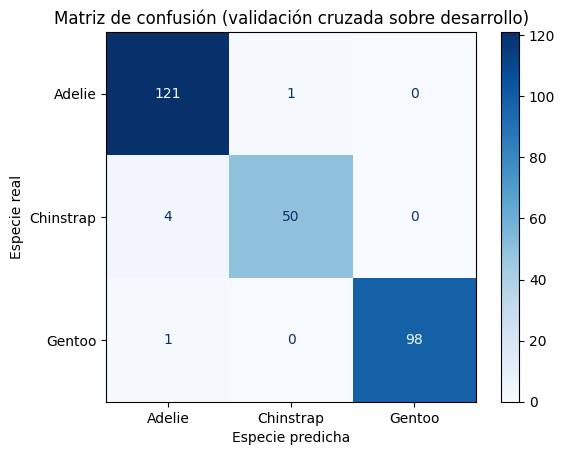

In [20]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import (confusion_matrix, precision_recall_fscore_support,
                             accuracy_score, f1_score, ConfusionMatrixDisplay)

modelo_cls = Pipeline([
    ("imputador", SimpleImputer(strategy="mean")),
    ("escalador", StandardScaler()),
    ("modelo", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])
pred_cv = cross_val_predict(modelo_cls, X_cls, y_cls, cv=cv)

clases = ["Adelie", "Chinstrap", "Gentoo"]
cm = confusion_matrix(y_cls, pred_cv, labels=clases)
matriz = pd.DataFrame(cm, index=[f"real {c}" for c in clases],
                      columns=[f"pred. {c}" for c in clases])
display(matriz)

ConfusionMatrixDisplay.from_predictions(y_cls, pred_cv, labels=clases, cmap="Blues")
plt.title("Matriz de confusión (validación cruzada sobre desarrollo)")
plt.xlabel("Especie predicha"); plt.ylabel("Especie real")
plt.show()

In [21]:
prec, rec, f1, soporte = precision_recall_fscore_support(y_cls, pred_cv, labels=clases)
tabla_clases = pd.DataFrame({"precisión": prec, "recall": rec, "F1": f1, "soporte": soporte}, index=clases)
macro = pd.DataFrame({"precisión": [prec.mean()], "recall": [rec.mean()], "F1": [f1.mean()],
                      "soporte": [soporte.sum()]}, index=["macro (promedio simple)"])
tabla_clases = pd.concat([tabla_clases, macro]).round(4)
display(tabla_clases)

,precisión,recall,F1,soporte
Adelie,0.9603,0.9918,0.9758,122
Chinstrap,0.9804,0.9259,0.9524,54
Gentoo,1.0000,0.9899,0.9949,99
macro (promedio simple),0.9802,0.9692,0.9744,275


In [22]:
pares = {f"{clases[i]} / {clases[j]}": cm[i, j] + cm[j, i] for i in range(3) for j in range(i + 1, 3)}
display(pd.Series(pares, name="confusiones (ambos sentidos)").sort_values(ascending=False))

print("Modelo   -> accuracy:", round(accuracy_score(y_cls, pred_cv), 4),
      "| F1 macro:", round(f1_score(y_cls, pred_cv, average="macro"), 4))
print("Baseline -> accuracy:", round(baseline_mayoritaria["test_accuracy"].mean(), 4),
      "| F1 macro:", round(baseline_mayoritaria["test_f1_macro"].mean(), 4))

Adelie / Chinstrap    5
Adelie / Gentoo       1
Chinstrap / Gentoo    0
Name: confusiones (ambos sentidos), dtype: int64

Modelo   -> accuracy: 0.9782 | F1 macro: 0.9744
Baseline -> accuracy: 0.4436 | F1 macro: 0.2049


<a id="ej9"></a>
## Ejercicio 9. Métricas de regresión

**Objetivo:** comparar MAE, RMSE y R² fuera de muestra.

### Parte A. Cálculo manual

Valores reales: [10, 12, 18, 20]. Predicciones: [11, 10, 17, 26]. Error = real − predicción.

| Caso | Real | Predicción | Error con signo | Error absoluto | Error cuadrado |
|---|---|---|---|---|---|
| 1 | 10 | 11 | −1 | 1 | 1 |
| 2 | 12 | 10 | 2 | 2 | 4 |
| 3 | 18 | 17 | 1 | 1 | 1 |
| 4 | 20 | 26 | −6 | 6 | 36 |
| Suma | | | −4 | 10 | 42 |

- **MAE** = 10 / 4 = 2,5
- **MSE** = 42 / 4 = 10,5; **RMSE** = √10,5 ≈ 3,24

**¿Por qué RMSE aumenta más ante el error de 6 unidades?** Porque el cuadrado amplifica los errores grandes: ese único error aporta 36 de los 42 puntos de la suma cuadrática (86 %), pero solo 6 de los 10 de la suma absoluta (60 %). Por eso RMSE queda por encima de MAE.

### Parte B. Predicción de masa corporal

**Protocolo.** Predictores: `bill_length_mm`, `bill_depth_mm` y `flipper_length_mm`. Objetivo: `body_mass_g`. Se usan las 273 filas de desarrollo con masa conocida y los mismos 5 folds de regresión del Ejercicio 7 (estratificados por `species`, semilla 42). Modelo: regresión lineal en un `Pipeline` con imputación por media y estandarización, ajustadas dentro de cada fold.

In [23]:
reales = np.array([10, 12, 18, 20]); preds = np.array([11, 10, 17, 26])
err = reales - preds
print("Errores con signo:", err)
print("Errores absolutos:", np.abs(err))
print("Errores cuadrados:", err ** 2)
print("MAE:", np.abs(err).mean(), "| MSE:", (err ** 2).mean(), "| RMSE:", round(np.sqrt((err ** 2).mean()), 4))

Errores con signo: [-1  2  1 -6]
Errores absolutos: [1 2 1 6]
Errores cuadrados: [ 1  4  1 36]
MAE: 2.5 | MSE: 10.5 | RMSE: 3.2404


In [24]:
from sklearn.linear_model import LinearRegression
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

modelo_lineal = Pipeline([
    ("imputador", SimpleImputer(strategy="mean")),
    ("escalador", StandardScaler()),
    ("modelo", LinearRegression()),
])
res_lineal = cross_validate(modelo_lineal, X_reg, y_reg, cv=folds_reg, scoring=metricas_reg)

In [25]:
preproc = ColumnTransformer([
    ("num", Pipeline([("imputador", SimpleImputer(strategy="mean")),
                      ("escalador", StandardScaler())]), pred_reg),
    ("cat", OneHotEncoder(handle_unknown="ignore"), ["species"]),
])
modelo_especie = Pipeline([("preproc", preproc), ("modelo", LinearRegression())])

X_reg_sp = des_reg[pred_reg + ["species"]]
res_especie = cross_validate(modelo_especie, X_reg_sp, y_reg, cv=folds_reg, scoring=metricas_reg)

In [26]:
def fila_reg(nombre, res):
    return {"Modelo": nombre,
            "MAE (g)": -res["test_mae"].mean(), "MAE desvío": res["test_mae"].std(),
            "RMSE (g)": -res["test_rmse"].mean(), "RMSE desvío": res["test_rmse"].std(),
            "R²": res["test_r2"].mean(), "R² desvío": res["test_r2"].std()}

tabla_reg_modelos = pd.DataFrame([
    fila_reg("Baseline: media", base_media),
    fila_reg("Baseline: mediana", base_mediana),
    fila_reg("Regresión lineal (3 medidas)", res_lineal),
    fila_reg("Regresión lineal + species", res_especie),
]).round(4)
display(tabla_reg_modelos)

,Modelo,MAE (g),MAE desvío,RMSE (g),RMSE desvío,R²,R² desvío
0,Baseline: media,680.6843,51.9625,803.1546,45.5554,-0.0009,0.0010
1,Baseline: mediana,673.8990,48.2911,818.4856,43.4409,-0.0400,0.0151
2,Regresión lineal (3 medidas),322.9042,28.9681,403.8653,33.7864,0.7457,0.0331
3,Regresión lineal + species,264.5447,8.7444,332.9127,13.3047,0.8276,0.0079


**Comparación de modelos y baselines (media ± desvío entre folds):**

| Modelo | MAE (g) | RMSE (g) | R² |
|---|---|---|---|
| Baseline: media | 680,7 ± 52,0 | 803,2 ± 45,6 | −0,0009 ± 0,0010 |
| Baseline: mediana | 673,9 ± 48,3 | 818,5 ± 43,4 | −0,0400 ± 0,0151 |
| Regresión lineal (3 medidas) | 322,9 ± 29,0 | 403,9 ± 33,8 | 0,7457 ± 0,0331 |
| Regresión lineal + `species` (extensión) | 264,5 ± 8,7 | 332,9 ± 13,3 | 0,8276 ± 0,0079 |

**Interpretación en unidades del problema.**
- Con tres medidas del pico y la aleta, el modelo se equivoca en promedio unos 323 g (MAE) al estimar la masa de un pingüino cuya masa media ronda los 4211 g. El baseline de media se equivoca unos 681 g, así que el modelo reduce el error cerca de un 53 %.
- El RMSE (404 g) es mayor que el MAE (323 g) porque los errores grandes pesan más en RMSE.
- El R² de 0,75 indica que el modelo explica aproximadamente el 75 % de la variabilidad de la masa respecto de predecir siempre la media.
- Los baselines tienen R² cercano a 0 o ligeramente negativo, como corresponde a una referencia sin información.

**¿Qué significaría un R² negativo fuera de muestra?** El R² compara el error del modelo con el de predecir siempre la media de los datos de validación. Un valor negativo indica que el modelo erra más que esa predicción constante, es decir, que es peor que no tener modelo (por ejemplo, por sobreajuste o por un preprocesamiento inadecuado). Los baselines muestran valores levemente negativos porque su media o mediana de entrenamiento no coincide exactamente con la de cada fold de validación.

**¿Qué métrica sería principal si los errores grandes fueran especialmente costosos?** El RMSE, porque eleva los errores al cuadrado y penaliza más las equivocaciones grandes. Por ejemplo, si la masa estimada se usara para calcular una dosis de anestesia o de alimento, un error grande sería mucho más grave que varios pequeños.

### Extensión: incorporar `species` como predictor

Se agregó `species` con codificación one-hot ajustada dentro del pipeline (`ColumnTransformer`). El MAE bajó de 322,9 g a 264,5 g, el RMSE de 403,9 g a 332,9 g y el R² subió de 0,746 a 0,828. Además, la dispersión entre folds se redujo (desvío del MAE de 29,0 g a 8,7 g).

**Qué pregunta distinta responde el nuevo modelo.** El primer modelo responde: ¿cuánto pesa un pingüino a partir de las medidas de su pico y su aleta? El segundo responde: ¿cuánto pesa un pingüino *cuya especie ya conocemos*, dadas esas medidas? Es una pregunta condicional a una información adicional. Sirve si la especie está disponible en el momento de estimar la masa; si hubiera que predecirla primero, sus errores se propagarían a la estimación de masa. No hay fuga porque aquí la especie es un predictor y no el objetivo.

### Conclusión

La regresión lineal supera ampliamente a los baselines (R² de 0,75 frente a valores cercanos a 0) y su error típico está en el orden de 320 g. Incorporar la especie mejora la precisión y la estabilidad, pero cambia la pregunta que el modelo responde.

<a id="ej10"></a>
## Ejercicio 10. Evaluación de clustering

**Objetivo:** evaluar grupos sin confundir calidad geométrica con utilidad sustantiva.

In [27]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples, adjusted_rand_score

X_clu = StandardScaler().fit_transform(SimpleImputer(strategy="mean").fit_transform(desarrollo_rec[predictores]))

semillas = RANDOM_STATE + np.arange(20)
filas = []
for K in range(2, 7):
    sil, ine, labs = [], [], []
    for s in semillas:
        km = KMeans(n_clusters=K, n_init=1, random_state=int(s)).fit(X_clu)   # una sola inicialización por semilla
        sil.append(silhouette_score(X_clu, km.labels_)); ine.append(km.inertia_); labs.append(km.labels_)
    ref = labs[int(np.argmin(ine))]                       # solución de menor inercia como referencia
    ari = [adjusted_rand_score(ref, l) for l in labs]     # 1 = misma partición
    filas.append({"K": K, "silhouette media": np.mean(sil), "silhouette desvío": np.std(sil),
                  "silhouette mín": np.min(sil), "silhouette máx": np.max(sil),
                  "soluciones distintas": len(set(np.round(ine, 3))),
                  "ARI medio": np.mean(ari), "ARI mínimo": np.min(ari)})
tabla_sil = pd.DataFrame(filas).round(4)
display(tabla_sil)

,K,silhouette media,silhouette desvío,silhouette mín,silhouette máx,soluciones distintas,ARI medio,ARI mínimo
0,2,0.5318,0.0000,0.5318,0.5318,1,1.0000,1.0000
1,3,0.4502,0.0068,0.4339,0.4540,4,0.8906,0.4690
2,4,0.4175,0.0127,0.4044,0.4311,6,0.7901,0.5874
3,5,0.3836,0.0047,0.3705,0.3954,8,0.9252,0.6446
4,6,0.3488,0.0165,0.3219,0.3714,16,0.8318,0.5764


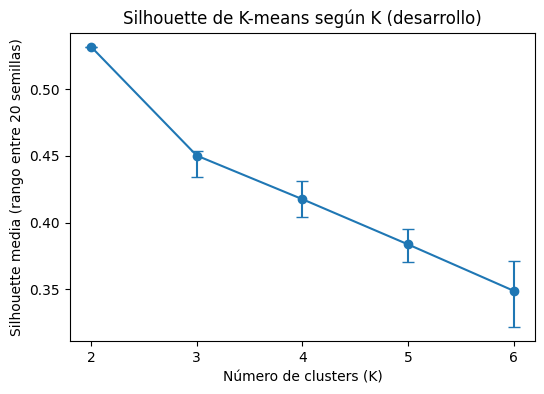

In [28]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.errorbar(tabla_sil["K"], tabla_sil["silhouette media"],
            yerr=[tabla_sil["silhouette media"] - tabla_sil["silhouette mín"],
                  tabla_sil["silhouette máx"] - tabla_sil["silhouette media"]],
            fmt="o-", capsize=4)
ax.set_xlabel("Número de clusters (K)"); ax.set_ylabel("Silhouette media (rango entre 20 semillas)")
ax.set_title("Silhouette de K-means según K (desarrollo)"); ax.set_xticks(range(2, 7))
plt.show()

In [29]:
K_ELEGIDO = 2
km_final = KMeans(n_clusters=K_ELEGIDO, n_init=10, random_state=RANDOM_STATE).fit(X_clu)

clu = desarrollo_rec.copy()
clu["cluster"] = km_final.labels_
clu["silhouette"] = silhouette_samples(X_clu, km_final.labels_)

perfiles = clu.groupby("cluster")[predictores].mean().round(1)
perfiles["n"] = clu.groupby("cluster").size()
perfiles["silhouette media"] = clu.groupby("cluster")["silhouette"].mean().round(3)
display(perfiles)

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,n,silhouette media
cluster,,,,,,
0,47.7,14.9,217.0,5083.9,98,0.619
1,42.0,18.4,191.8,3722.6,177,0.483


In [30]:
display(pd.crosstab(clu["cluster"], clu["species"], margins=True))

species,Adelie,Chinstrap,Gentoo,All
cluster,,,,
0,0,0,98,98
1,122,54,1,177
All,122,54,99,275


In [31]:
bajos = clu.nsmallest(10, "silhouette")[["species", "island", "sex"] + predictores + ["cluster", "silhouette"]].round(3)
display(bajos)
print("Silhouette negativas:", (clu["silhouette"] < 0).sum(), "| menores a 0,2:", (clu["silhouette"] < 0.2).sum())

,species,island,sex,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,cluster,silhouette
313,Chinstrap,Dream,male,52.0,20.7,210.0,4800.0,1,0.053
315,Chinstrap,Dream,male,53.5,19.9,205.0,4500.0,1,0.100
342,Chinstrap,Dream,male,50.8,19.0,210.0,4100.0,1,0.109
339,Chinstrap,Dream,male,55.8,19.8,207.0,4000.0,1,0.112
305,Chinstrap,Dream,male,52.8,20.0,205.0,4550.0,1,0.113
321,Chinstrap,Dream,male,50.8,18.5,201.0,4450.0,1,0.117
323,Chinstrap,Dream,male,49.0,19.6,212.0,4300.0,1,0.123
289,Chinstrap,Dream,male,52.0,18.1,201.0,4050.0,1,0.151
293,Chinstrap,Dream,female,58.0,17.8,181.0,3700.0,1,0.194
309,Chinstrap,Dream,male,51.0,18.8,203.0,4100.0,1,0.212


Silhouette negativas: 0 | menores a 0,2: 9


In [32]:
km3 = KMeans(n_clusters=3, n_init=10, random_state=RANDOM_STATE).fit(X_clu)
display(pd.crosstab(km3.labels_, clu["species"].values, rownames=["cluster (K=3)"], colnames=["species"], margins=True))
s3 = silhouette_samples(X_clu, km3.labels_)
print("Silhouette media K=3 por cluster:", pd.Series(s3).groupby(km3.labels_).mean().round(3).to_dict())

species,Adelie,Chinstrap,Gentoo,All
cluster (K=3),,,,
0,103,5,0,108
1,0,0,98,98
2,19,49,1,69
All,122,54,99,275


Silhouette media K=3 por cluster: {0: 0.438, 1: 0.573, 2: 0.311}


**Protocolo.** Variables: `bill_length_mm`, `bill_depth_mm`, `flipper_length_mm` y `body_mass_g`, imputadas con la media y estandarizadas. `species`, `island` y `sex` no intervienen en la construcción de los clusters. Se usa el conjunto de desarrollo (275 filas). K-means para K = 2 a 6, con 20 semillas (42 a 61) y una sola inicialización por semilla, para exponer la sensibilidad a la inicialización.

### Silhouette y estabilidad

| K | Silhouette media | Desvío | Rango | Soluciones distintas | ARI medio | ARI mínimo |
|---|---|---|---|---|---|---|
| 2 | 0,5318 | 0,0000 | 0,5318 – 0,5318 | 1 | 1,000 | 1,000 |
| 3 | 0,4502 | 0,0068 | 0,4339 – 0,4540 | 4 | 0,891 | 0,469 |
| 4 | 0,4175 | 0,0127 | 0,4044 – 0,4311 | 6 | 0,790 | 0,587 |
| 5 | 0,3836 | 0,0047 | 0,3705 – 0,3954 | 8 | 0,925 | 0,645 |
| 6 | 0,3488 | 0,0165 | 0,3219 – 0,3714 | 16 | 0,832 | 0,576 |

(Figura: silhouette media según K, con el rango entre semillas.)

### Selección de la solución

Se elige **K = 2**, considerando únicamente criterios internos, antes de comparar con `species`:
- **Cohesión y separación:** tiene el mayor silhouette (0,532), y ningún caso tiene silhouette negativa.
- **Estabilidad:** las 20 semillas producen la misma partición (ARI = 1). Para K ≥ 3 aparecen varias soluciones distintas.
- **Simplicidad:** es la solución con menos grupos.
- **Interpretabilidad:** dos perfiles claramente distintos (ver abajo).

### Perfiles de los clusters (valores medios en unidades originales)

| Cluster | n | Long. pico (mm) | Prof. pico (mm) | Long. aleta (mm) | Masa (g) | Silhouette media |
|---|---|---|---|---|---|---|
| Grande | 98 | 47,7 | 14,9 | 217,0 | 5083,9 | 0,619 |
| Pequeño | 177 | 42,0 | 18,4 | 191,8 | 3722,6 | 0,483 |

El cluster grande agrupa pingüinos pesados, de aleta larga y pico poco profundo. El pequeño agrupa pingüinos más livianos, de aleta más corta y pico más profundo. Las medias excluyen los valores faltantes, pero los tamaños incluyen las 2 filas sin medidas, imputadas y asignadas al cluster pequeño.

### Evaluación externa: tabla cruzada con `species`

| Cluster | Adelie | Chinstrap | Gentoo | Total |
|---|---|---|---|---|
| Grande | 0 | 0 | 98 | 98 |
| Pequeño | 122 | 54 | 1 | 177 |

El cluster grande contiene a todos los Gentoo con medidas. El pequeño mezcla Adelie y Chinstrap. El único Gentoo del cluster pequeño es una fila sin ninguna medida, que la imputación dejó en el centro de los datos.

### Casos con silhouette baja

No hay silhouette negativas; 9 filas quedan por debajo de 0,2. Las diez más bajas son Chinstrap (nueve machos de Dream y una hembra) con medidas grandes (aleta de 181 a 212 mm y pico largo): individuos del cluster pequeño que se parecen en parte al grande. Son los casos de frontera de la solución.

### Análisis de sensibilidad posterior (no usado para elegir K)

Con K = 3 el silhouette baja a 0,454, y los clusters son: uno con 103 Adelie y 5 Chinstrap, otro con los 98 Gentoo y un tercero de 69 con 19 Adelie, 49 Chinstrap y 1 Gentoo (silhouette media por cluster: 0,438, 0,573 y 0,311). Separa mejor a Chinstrap que K = 2, aunque con peor silhouette y con un cluster mixto.

### Preguntas de análisis

**1. ¿Por qué es imprescindible escalar antes de usar distancias con estas variables?**
Porque K-means usa distancia euclídea y las variables tienen escalas muy distintas: la masa tiene un desvío de unos 806 g y la profundidad del pico de unos 2 mm. Sin escalar, la masa dominaría casi toda la distancia y las otras tres medidas apenas influirían.

**2. ¿Un silhouette alto demuestra que los grupos tienen significado biológico?**
No. El silhouette mide cohesión y separación geométrica en el espacio de las cuatro variables; no sabe nada de biología. K = 2 tiene el mayor silhouette pero junta a Adelie y Chinstrap, mientras que K = 3 tiene menor silhouette y separa mejor a Chinstrap. El significado se evalúa con información externa y criterio del dominio.

**3. ¿Por qué distintas semillas pueden producir soluciones diferentes?**
K-means parte de centros iniciales aleatorios y converge a un óptimo local; otra inicialización puede terminar en otra solución. Con una sola inicialización por semilla, K = 2 dio siempre la misma partición, K = 3 dio 4 soluciones distintas (ARI mínimo 0,47) y K = 6 hasta 16.

**4. ¿Qué significa que un cluster contenga varias especies?**
Que las cuatro medidas usadas no separan esas especies mejor de lo que varían dentro de cada una: hay solapamiento morfológico entre Adelie y Chinstrap. No es un error del algoritmo, que no conoce las especies: encontró una estructura de tamaño, no taxonómica.

**5. ¿Qué información adicional aporta la estabilidad frente al resultado de una única ejecución?**
Permite distinguir una estructura reproducible de un artefacto de la inicialización. Una sola ejecución puede ser una solución local favorable o desfavorable; repetirla muestra la variabilidad (desvío y rango del silhouette, ARI) y qué valores de K dan resultados confiables.

### ¿Los grupos podrían apoyar una decisión concreta?

Sí, de forma limitada: como un cribado morfológico rápido. Los individuos del cluster grande son casi con seguridad Gentoo, y los del pequeño requieren una verificación adicional para distinguir Adelie de Chinstrap. No reemplaza a un clasificador supervisado, que en el Ejercicio 8 llegó a una accuracy de 0,978.

### Interpretación: evidencia geométrica y significado de dominio

- **Evidencia geométrica:** K = 2 es la solución más cohesionada, separada y estable (silhouette 0,532, ARI = 1 entre semillas).
- **Significado de dominio:** esa solución recupera una separación biológica real (Gentoo frente al resto), pero no distingue Adelie de Chinstrap. El silhouette alto no lo anticipaba: lo reveló la comparación externa.

### Conclusión

K = 2 se elige por criterios internos y resulta ser una partición estable y fácil de describir. La comparación con `species` muestra que captura la diferencia de tamaño entre Gentoo y las otras dos especies, pero no resuelve el solapamiento entre Adelie y Chinstrap.

<a id="ej11"></a>
## Ejercicio 11. Validación cruzada del procedimiento completo

**Objetivo:** estimar desempeño y variabilidad mediante validación cruzada sobre el conjunto de desarrollo.

In [33]:
from sklearn.tree import DecisionTreeClassifier

modelos = {
    "Regresión logística": Pipeline([
        ("imputador", SimpleImputer(strategy="mean")),
        ("escalador", StandardScaler()),
        ("modelo", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    ]),
    "Árbol de decisión": Pipeline([
        ("imputador", SimpleImputer(strategy="mean")),
        ("modelo", DecisionTreeClassifier(random_state=RANDOM_STATE)),
    ]),
}
metricas_cls = {"accuracy": "accuracy", "f1_macro": "f1_macro"}
resultados = {nombre: cross_validate(m, X_cls, y_cls, cv=cv, scoring=metricas_cls)
              for nombre, m in modelos.items()}

In [34]:
filas = []
for nombre, r in resultados.items():
    for i in range(K_FOLDS):
        filas.append({"modelo": nombre, "fold": i + 1,
                      "accuracy": r["test_accuracy"][i], "F1 macro": r["test_f1_macro"][i]})
por_fold = pd.DataFrame(filas)
n_valid = len(desarrollo_rec) // K_FOLDS                       # filas por fold de validación (55)
por_fold["errores"] = ((1 - por_fold["accuracy"]) * n_valid).round().astype(int)
display(por_fold.round(4))

,modelo,fold,accuracy,F1 macro,errores
0,Regresión logística,1,0.9636,0.9533,2
1,Regresión logística,2,1.0000,1.0000,0
2,Regresión logística,3,1.0000,1.0000,0
3,Regresión logística,4,0.9273,0.9132,4
4,Regresión logística,5,1.0000,1.0000,0
5,Árbol de decisión,1,0.9455,0.9320,3
6,Árbol de decisión,2,0.9636,0.9564,2
7,Árbol de decisión,3,0.9818,0.9773,1
8,Árbol de decisión,4,0.9091,0.8901,5
9,Árbol de decisión,5,0.9818,0.9848,1


In [35]:
def desvío(x):
    return x.std(ddof=0)      # desvío poblacional, igual que en los ejercicios anteriores

resumen = por_fold.groupby("modelo")[["accuracy", "F1 macro"]].agg(["mean", desvío, "min", "max"]).round(4)
display(resumen)
print(por_fold.groupby("modelo")["errores"].sum())

accuracy                         F1 macro                  \
                        mean  desvío     min     max     mean  desvío     min   
modelo                                                                          
Regresión logística   0.9782  0.0291  0.9273  1.0000   0.9733  0.0351  0.9132   
Árbol de decisión     0.9564  0.0272  0.9091  0.9818   0.9481  0.0343  0.8901   

                             
                        max  
modelo                       
Regresión logística  1.0000  
Árbol de decisión    0.9848

modelo
Regresión logística     6
Árbol de decisión      12
Name: errores, dtype: int64


### Diseño de la validación

- **Datos:** conjunto de desarrollo (275 filas). La prueba permanece cerrada.
- **Folds:** `StratifiedKFold` con K = 5, mezcla de filas y semilla 42 (los mismos folds que en el Ejercicio 4). En cada fold, 220 filas entrenan y 55 validan.
- **Predictores:** `bill_length_mm`, `bill_depth_mm`, `flipper_length_mm` y `body_mass_g`. Objetivo: `species`.
- **Modelos y pipelines** (todo se ajusta con el entrenamiento de cada fold):
  - Regresión logística multinomial: imputación por media, estandarización y modelo (`max_iter=1000`).
  - Árbol de decisión (hiperparámetros por defecto, `random_state=42`): imputación por media y modelo. No lleva escalado porque un árbol no lo requiere; se imputa para que ambos modelos reciban los mismos datos de entrada.
- **Métricas:** accuracy y F1 macro en cada fold. Desvío poblacional (`ddof=0`).

### Resultados por fold

| Fold | Logística: accuracy | Logística: F1 macro | Logística: errores | Árbol: accuracy | Árbol: F1 macro | Árbol: errores |
|---|---|---|---|---|---|---|
| 1 | 0,9636 | 0,9533 | 2 | 0,9455 | 0,9320 | 3 |
| 2 | 1,0000 | 1,0000 | 0 | 0,9636 | 0,9564 | 2 |
| 3 | 1,0000 | 1,0000 | 0 | 0,9818 | 0,9773 | 1 |
| 4 | 0,9273 | 0,9132 | 4 | 0,9091 | 0,8901 | 5 |
| 5 | 1,0000 | 1,0000 | 0 | 0,9818 | 0,9848 | 1 |

### Resumen comparativo

| Modelo | Métrica | Promedio | Desvío | Mínimo | Máximo |
|---|---|---|---|---|---|
| Regresión logística | accuracy | 0,9782 | 0,0291 | 0,9273 | 1,0000 |
| Regresión logística | F1 macro | 0,9733 | 0,0351 | 0,9132 | 1,0000 |
| Árbol de decisión | accuracy | 0,9564 | 0,0272 | 0,9091 | 0,9818 |
| Árbol de decisión | F1 macro | 0,9481 | 0,0343 | 0,8901 | 0,9848 |

En total, la regresión logística comete 6 errores sobre las 275 filas y el árbol de decisión, 12. La logística supera al árbol en los cinco folds, tanto en accuracy como en F1 macro.

### Selección provisional

Se selecciona **provisionalmente la regresión logística**: tiene mayor promedio en ambas métricas, mejor valor mínimo y no es superada por el árbol en ningún fold. La selección es provisional por dos razones: la diferencia (unos 2 puntos de accuracy) se estima con solo 5 folds de 55 filas, y el árbol se evaluó con hiperparámetros por defecto, sin límite de profundidad. En el Ejercicio 12 se estudiará cómo cambia su desempeño con la complejidad.

### Preguntas de análisis

**1. ¿Por qué informar solamente el promedio oculta información?**
Porque no muestra la dispersión ni el peor caso. La regresión logística tiene promedio 0,978, pero un fold llegó a 0,927 (4 errores) y otros a 1,0. El promedio tampoco dice si la ventaja de un modelo es consistente o se debe a un solo fold.

**2. ¿Qué indicaría una dispersión grande entre folds?**
Que el desempeño depende de qué casos caen en validación, y que la estimación es poco precisa. Puede deberse a pocos datos o a clases poco frecuentes en cada fold, a subgrupos heterogéneos, a casos atípicos o a un modelo inestable. Aquí cada fold valida con 55 filas, y un solo error equivale a 1,8 puntos de accuracy.

**3. ¿Por qué los modelos deben utilizar los mismos folds?**
Para que la comparación sea pareada: las diferencias reflejan al modelo y no la suerte de cada partición. Con folds distintos, un modelo podría parecer mejor simplemente por validar sobre casos más fáciles.

**4. ¿Dónde deben aprenderse imputación, escalado y cualquier selección de atributos?**
Dentro de cada fold, solo con las filas de entrenamiento de ese fold, y luego aplicarse al fold de validación. Por eso van dentro del `Pipeline`.

**5. ¿Qué parte del proceso permanece completamente fuera del ciclo?**
El conjunto de prueba (69 filas): ni sus datos ni sus resultados participan en la imputación, el escalado, la selección ni la comparación de modelos. También quedan fuera, por estar fijadas antes, la definición de la partición y la semilla.

### Conclusión

Con validación cruzada sobre desarrollo, la regresión logística (accuracy 0,978; F1 macro 0,973) supera al árbol con configuración por defecto (0,956; 0,948) en los cinco folds. La elección es provisional hasta estudiar la complejidad del árbol en el Ejercicio 12.

<a id="ej12"></a>
## Ejercicio 12. Subajuste, equilibrio y sobreajuste

**Objetivo:** relacionar la capacidad del modelo con el desempeño de entrenamiento y validación.

In [36]:
profundidades = [1, 2, 3, 5, 8, None]
filas = []
for p in profundidades:
    arbol = Pipeline([
        ("imputador", SimpleImputer(strategy="mean")),
        ("modelo", DecisionTreeClassifier(max_depth=p, random_state=RANDOM_STATE)),
    ])
    r = cross_validate(arbol, X_cls, y_cls, cv=cv,
                       scoring={"accuracy": "accuracy", "f1_macro": "f1_macro"},
                       return_train_score=True, return_estimator=True)
    filas.append({
        "max_depth": "sin límite" if p is None else p,
        "profundidad real": np.mean([e["modelo"].get_depth() for e in r["estimator"]]),
        "entrenamiento (acc.)": r["train_accuracy"].mean(),
        "validación (acc.)": r["test_accuracy"].mean(),
        "validación desvío": r["test_accuracy"].std(),
        "validación mín": r["test_accuracy"].min(),
        "validación máx": r["test_accuracy"].max(),
        "brecha": r["train_accuracy"].mean() - r["test_accuracy"].mean(),
        "validación (F1 macro)": r["test_f1_macro"].mean(),
    })
tabla_prof = pd.DataFrame(filas)
display(tabla_prof.round(4))

,max_depth,profundidad real,entrenamiento (acc.),validación (acc.),validación desvío,validación mín,validación máx,brecha,validación (F1 macro)
0,1,1.0,0.7927,0.7891,0.0185,0.7636,0.8182,0.0036,0.5920
1,2,2.0,0.9600,0.9527,0.0295,0.9091,1.0000,0.0073,0.9435
2,3,3.0,0.9664,0.9455,0.0325,0.9091,1.0000,0.0209,0.9343
3,5,5.0,0.9945,0.9564,0.0272,0.9091,0.9818,0.0382,0.9481
4,8,6.0,0.9973,0.9564,0.0272,0.9091,0.9818,0.0409,0.9481
5,sin límite,6.0,0.9973,0.9564,0.0272,0.9091,0.9818,0.0409,0.9481


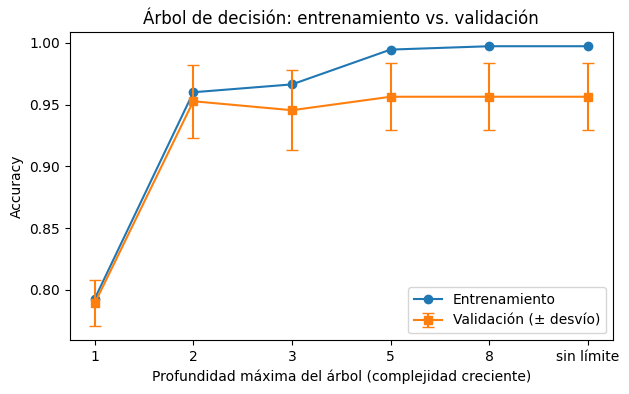

In [37]:
x = np.arange(len(tabla_prof))
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x, tabla_prof["entrenamiento (acc.)"], "o-", label="Entrenamiento")
ax.errorbar(x, tabla_prof["validación (acc.)"], yerr=tabla_prof["validación desvío"],
            fmt="s-", capsize=4, label="Validación (± desvío)")
ax.set_xticks(x); ax.set_xticklabels(tabla_prof["max_depth"].astype(str))
ax.set_xlabel("Profundidad máxima del árbol (complejidad creciente)")
ax.set_ylabel("Accuracy")
ax.set_title("Árbol de decisión: entrenamiento vs. validación")
ax.legend()
plt.show()

**Protocolo.** Árboles de decisión (`DecisionTreeClassifier`, `random_state=42`) con imputación por media dentro del pipeline, evaluados con los mismos 5 folds estratificados del Ejercicio 4 sobre el conjunto de desarrollo. Se varía `max_depth` en 1, 2, 3, 5, 8 y sin límite. La prueba permanece cerrada. Métrica principal: accuracy; se informa también el F1 macro de validación.

### Resultados por configuración

| max_depth | Profundidad real | Entrenamiento (accuracy) | Validación (accuracy, media ± desvío) | Mín – máx (validación) | Brecha | F1 macro (validación) | Diagnóstico |
|---|---|---|---|---|---|---|---|
| 1 | 1 | 0,7927 | 0,7891 ± 0,0185 | 0,7636 – 0,8182 | 0,004 | 0,5920 | Subajuste |
| 2 | 2 | 0,9600 | 0,9527 ± 0,0295 | 0,9091 – 1,0000 | 0,007 | 0,9435 | Equilibrio |
| 3 | 3 | 0,9664 | 0,9455 ± 0,0325 | 0,9091 – 1,0000 | 0,021 | 0,9343 | Equilibrio (transición) |
| 5 | 5 | 0,9945 | 0,9564 ± 0,0272 | 0,9091 – 0,9818 | 0,038 | 0,9481 | Posible sobreajuste leve |
| 8 | 6 | 0,9973 | 0,9564 ± 0,0272 | 0,9091 – 0,9818 | 0,041 | 0,9481 | Posible sobreajuste leve |
| Sin límite | 6 | 0,9973 | 0,9564 ± 0,0272 | 0,9091 – 0,9818 | 0,041 | 0,9481 | Posible sobreajuste leve |

(Figura: curva de accuracy de entrenamiento y validación según la profundidad máxima.)

**Observaciones.**
- Con profundidad 8 y sin límite el resultado es idéntico: el árbol sin límite se detiene solo a profundidad 6, cuando todas sus hojas son puras.
- Con profundidad 1 el árbol tiene solo 2 hojas y no puede predecir las tres especies, de ahí el F1 macro de 0,59.
- El entrenamiento no llega a 1,0 porque dos filas sin ninguna medida (una Adelie y una Gentoo) quedan idénticas tras la imputación y no pueden clasificarse bien ambas.

### Selección

Se elige **profundidad máxima = 2**, considerando tres criterios:
- **Desempeño:** su accuracy de validación (0,9527) queda a 0,4 puntos del mejor valor (0,9564), una diferencia mucho menor que el desvío entre folds (aprox. 0,03).
- **Estabilidad y brecha:** tiene la menor brecha entre entrenamiento y validación entre los modelos competitivos (0,007).
- **Simplicidad:** es el árbol más pequeño que rinde como los más complejos (4 hojas, interpretable).

Esta elección es válida *dentro de la familia de árboles*. Ningún árbol (0,953 con profundidad 2; 0,956 como máximo) alcanza a la regresión logística del Ejercicio 11 (0,978), por lo que la selección provisional de ese ejercicio no cambia.

### Preguntas de análisis

**1. ¿Qué patrón se espera bajo subajuste?**
Desempeño bajo tanto en entrenamiento como en validación, con una brecha pequeña: el modelo es demasiado simple para capturar la estructura. Es lo que ocurre con profundidad 1 (0,79 y 0,79).

**2. ¿Qué brecha entre entrenamiento y validación sugiere sobreajuste?**
Un entrenamiento muy alto con una validación claramente menor y estancada, y una brecha que crece con la complejidad sin que la validación mejore. Aquí el entrenamiento llega a 0,997 mientras la validación se queda en 0,956 (brecha de 4 puntos). Es un sobreajuste leve: la validación no empeora, solo deja de mejorar.

**3. ¿Qué riesgo presenta elegir la configuración mediante el mejor resultado de entrenamiento?**
Se elegiría siempre el árbol más complejo (el que mejor memoriza), aunque no mejore la validación. El entrenamiento premia la memorización y da una estimación optimista de lo que ocurrirá con casos nuevos.

**4. ¿Qué papel cumple la simplicidad cuando dos configuraciones rinden de forma semejante?**
Es el criterio de desempate: el modelo más simple tiene menos riesgo de sobreajuste, es más interpretable, más estable y más barato de mantener. Aquí la profundidad 2 rinde como las demás dentro de la variabilidad entre folds.

### Conclusión

La capacidad del árbol mejora el desempeño hasta la profundidad 2; más allá, el entrenamiento sigue subiendo pero la validación se estanca. La profundidad 2 es el mejor compromiso entre desempeño, estabilidad y simplicidad.

<a id="evaluacion-final"></a>
## Evaluación final (Ejercicio 13)

**Objetivo:** obtener una estimación final sobre datos independientes de las decisiones del procedimiento.

In [38]:
import json

config_final = {
    "tarea": "clasificación multiclase de species",
    "predictores": predictores,
    "imputacion": "SimpleImputer(strategy='mean')",
    "escalado": "StandardScaler()",
    "modelo": "LogisticRegression(max_iter=1000, random_state=42)",
    "seleccion_de_atributos": "ninguna",
    "semilla": RANDOM_STATE,
    "metricas": ["accuracy", "f1_macro", "matriz de confusión"],
    "criterio_de_eleccion": "mayor accuracy y F1 macro medios en validación cruzada de 5 folds sobre desarrollo",
}
modelo_final = Pipeline([
    ("imputador", SimpleImputer(strategy="mean")),
    ("escalador", StandardScaler()),
    ("modelo", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])
with open("configuracion_final.json", "w", encoding="utf-8") as f:
    json.dump(config_final, f, indent=2, ensure_ascii=False)
print(json.dumps(config_final, indent=2, ensure_ascii=False))

{
  "tarea": "clasificación multiclase de species",
  "predictores": [
    "bill_length_mm",
    "bill_depth_mm",
    "flipper_length_mm",
    "body_mass_g"
  ],
  "imputacion": "SimpleImputer(strategy='mean')",
  "escalado": "StandardScaler()",
  "modelo": "LogisticRegression(max_iter=1000, random_state=42)",
  "seleccion_de_atributos": "ninguna",
  "semilla": 42,
  "metricas": [
    "accuracy",
    "f1_macro",
    "matriz de confusión"
  ],
  "criterio_de_eleccion": "mayor accuracy y F1 macro medios en validación cruzada de 5 folds sobre desarrollo"
}


,pred. Adelie,pred. Chinstrap,pred. Gentoo
real Adelie,30,0,0
real Chinstrap,0,14,0
real Gentoo,0,0,25


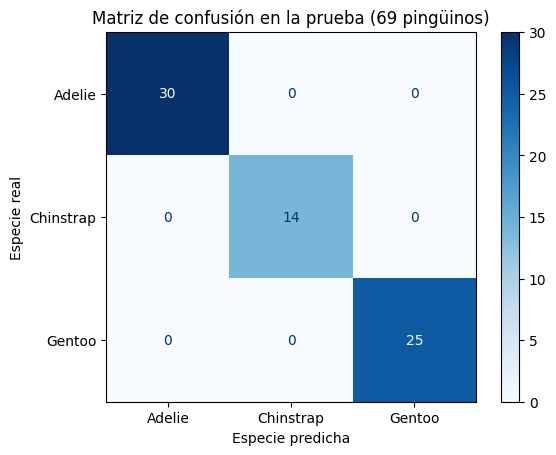

,precisión,recall,F1,soporte
Adelie,1.0,1.0,1.0,30
Chinstrap,1.0,1.0,1.0,14
Gentoo,1.0,1.0,1.0,25


Prueba -> accuracy: 1.0000 | F1 macro: 1.0000


In [39]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, precision_recall_fscore_support

X_des, y_des = desarrollo_rec[predictores], desarrollo_rec["species"]
X_pru, y_pru = prueba_rec[predictores], prueba_rec["species"]     # primera y única vez que se usa la prueba

modelo_final.fit(X_des, y_des)            # reajuste con TODO el conjunto de desarrollo
pred_pru = modelo_final.predict(X_pru)    # transformaciones aprendidas en desarrollo

clases = ["Adelie", "Chinstrap", "Gentoo"]
acc_pru = accuracy_score(y_pru, pred_pru)
f1_pru = f1_score(y_pru, pred_pru, average="macro")
cm_pru = confusion_matrix(y_pru, pred_pru, labels=clases)

display(pd.DataFrame(cm_pru, index=[f"real {c}" for c in clases], columns=[f"pred. {c}" for c in clases]))
ConfusionMatrixDisplay.from_predictions(y_pru, pred_pru, labels=clases, cmap="Blues")
plt.title("Matriz de confusión en la prueba (69 pingüinos)")
plt.xlabel("Especie predicha"); plt.ylabel("Especie real")
plt.show()

prec, rec, f1, soporte = precision_recall_fscore_support(y_pru, pred_pru, labels=clases)
display(pd.DataFrame({"precisión": prec, "recall": rec, "F1": f1, "soporte": soporte}, index=clases).round(4))
print(f"Prueba -> accuracy: {acc_pru:.4f} | F1 macro: {f1_pru:.4f}")

In [40]:
val = resultados["Regresión logística"]
comparacion = pd.DataFrame({
    "Validación (5 folds): media ± desvío": [f"{val['test_accuracy'].mean():.4f} ± {val['test_accuracy'].std():.4f}",
                                             f"{val['test_f1_macro'].mean():.4f} ± {val['test_f1_macro'].std():.4f}"],
    "Validación: rango entre folds": [f"{val['test_accuracy'].min():.4f} – {val['test_accuracy'].max():.4f}",
                                      f"{val['test_f1_macro'].min():.4f} – {val['test_f1_macro'].max():.4f}"],
    "Prueba (una sola vez)": [f"{acc_pru:.4f}", f"{f1_pru:.4f}"],
}, index=["accuracy", "F1 macro"])
display(comparacion)

def wilson(k, n, z=1.96):                 # intervalo de confianza del 95 % para una proporción
    ph = k / n; den = 1 + z**2 / n
    centro = (ph + z**2 / (2 * n)) / den
    mitad = z * np.sqrt(ph * (1 - ph) / n + z**2 / (4 * n * n)) / den
    return centro - mitad, centro + mitad

aciertos = int((pred_pru == y_pru.values).sum())
print("Aciertos:", aciertos, "de", len(y_pru), "| IC 95 % de la accuracy:", np.round(wilson(aciertos, len(y_pru)), 4))
print("Baseline (clase mayoritaria de entrenamiento) en prueba:", round((y_pru == y_des.value_counts().idxmax()).mean(), 4))
print("Faltantes en las medidas de la prueba:", int(prueba_rec[predictores].isna().sum().sum()))

,Validación (5 folds): media ± desvío,Validación: rango entre folds,Prueba (una sola vez)
accuracy,0.9782 ± 0.0291,0.9273 – 1.0000,1.0000
F1 macro,0.9733 ± 0.0351,0.9132 – 1.0000,1.0000


Aciertos: 69 de 69 | IC 95 % de la accuracy: [0.9473 1.    ]
Baseline (clase mayoritaria de entrenamiento) en prueba: 0.4348
Faltantes en las medidas de la prueba: 0


### Configuración final congelada (antes de abrir la prueba)

Esta configuración se escribió en `configuracion_final.json` antes de consultar la prueba.

| Elemento | Definición congelada |
|---|---|
| Tarea | Clasificación multiclase de `species` |
| Función de cada variable | **Objetivo:** `species`. **Predictores:** `bill_length_mm`, `bill_depth_mm`, `flipper_length_mm`, `body_mass_g`. **No utilizadas:** `island` (riesgo de atajo; no se evaluó su aporte), `sex` (11 faltantes; no se evaluó su aporte) y `year` (variable contextual, reservada para la extensión de transferencia) |
| Imputación | Media, aprendida con los datos de entrenamiento |
| Codificación | No aplica (solo predictores numéricos) |
| Escalado | `StandardScaler`, aprendido con los datos de entrenamiento |
| Selección de atributos | Ninguna |
| Modelo e hiperparámetros | `LogisticRegression(max_iter=1000)`, multinomial, `random_state=42` |
| Semilla | 42 |
| Métricas | Accuracy, F1 macro y matriz de confusión. Clase positiva: no aplica (problema multiclase; se usan promedios macro) |
| Criterio de elección | Mayor accuracy y F1 macro medios en validación cruzada de 5 folds sobre desarrollo |

**Justificación de la elección.** La regresión logística obtuvo accuracy 0,9782 y F1 macro 0,9733 en validación, contra 0,9564 y 0,9481 del árbol con configuración por defecto, y superó al árbol en los cinco folds. El mejor árbol de la exploración de profundidad (profundidad 2) alcanzó 0,9527, sin acercarse a la logística.

### Procedimiento

1. Reajuste del pipeline completo (imputación, escalado y modelo) con todo el conjunto de desarrollo (275 filas).
2. Aplicación a la prueba (69 filas) de las transformaciones aprendidas en desarrollo.
3. Cálculo de las métricas y de la matriz de confusión **una sola vez**.

### Resultados sobre la prueba

| | pred. Adelie | pred. Chinstrap | pred. Gentoo |
|---|---|---|---|
| real Adelie | 30 | 0 | 0 |
| real Chinstrap | 0 | 14 | 0 |
| real Gentoo | 0 | 0 | 25 |

| Especie | Precisión | Recall | F1 | Soporte |
|---|---|---|---|---|
| Adelie | 1,0000 | 1,0000 | 1,0000 | 30 |
| Chinstrap | 1,0000 | 1,0000 | 1,0000 | 14 |
| Gentoo | 1,0000 | 1,0000 | 1,0000 | 25 |

Accuracy 1,0000 y F1 macro 1,0000 (69 aciertos de 69). El baseline de clase mayoritaria da 0,4348 en la prueba.

### Comparación entre validación y prueba

| Métrica | Validación (5 folds, media ± desvío) | Rango entre folds | Prueba |
|---|---|---|---|
| Accuracy | 0,9782 ± 0,0291 | 0,9273 – 1,0000 | 1,0000 |
| F1 macro | 0,9733 ± 0,0351 | 0,9132 – 1,0000 | 1,0000 |

### Preguntas de análisis

**1. ¿La diferencia entre validación y prueba es compatible con la variabilidad observada entre folds?**
Sí. El resultado de la prueba (1,0) cae dentro del rango observado en validación: tres de los cinco folds ya habían dado 1,0, y la diferencia con la media (0,022) es de unos 0,75 desvíos entre folds. Además, la prueba no contiene ninguna de las filas sin medidas, que en validación eran imposibles de clasificar con las medidas corporales, por lo que es esperable que la prueba rinda algo mejor. La diferencia es de aproximadamente un error y medio en 69 casos.

**2. ¿Qué conclusiones están respaldadas por esta prueba y cuáles exceden la población evaluada?**
*Respaldadas:* para pingüinos nuevos de la misma población (islas Biscoe, Dream y Torgersen, años 2007 a 2009, mismo procedimiento de medición) con las cuatro medidas disponibles, el clasificador tiene un desempeño alto y muy superior al baseline (0,435). *Que exceden la población:* afirmar que el modelo es perfecto (con 69 casos, el intervalo del 95 % para la accuracy va de unos 0,947 a 1,0; y con 14 Chinstrap, el recall de esa especie tiene aún más incertidumbre), extender el resultado a otras islas, años, especies o procedimientos de medición (eso lo estudia la extensión de transferencia), o suponer el mismo desempeño en individuos sin medidas.

**3. ¿Qué nuevo conjunto independiente sería necesario si el resultado de prueba motiva cambios en el procedimiento?**
Una nueva muestra de evaluación que no haya intervenido en ninguna decisión: nuevas observaciones de la misma población (por ejemplo, de un período o campaña posterior) reservadas desde el inicio. Esta prueba, una vez usada para decidir, pasaría a funcionar como validación.

### Declaración sobre el uso de la prueba

- **Cuándo se consultó:** una única vez, en la celda de evaluación final, **después** de congelar la configuración en `configuracion_final.json`.
- **Decisiones tomadas antes de observar cualquier resultado:** unidad de análisis, criterio de partición y semilla (Ejercicios 3 y 4), K = 5 folds, estructura de los pipelines y métricas.
- **Decisiones tomadas tras observar resultados de validación (nunca de la prueba):** elegir la regresión logística frente al árbol (Ejercicio 11) y la exploración de la profundidad del árbol (Ejercicio 12).
- **Decisiones tomadas tras ver la prueba:** ninguna. La configuración no se modificó.

### Limitaciones

- La prueba tiene 69 filas: las estimaciones por especie son imprecisas, sobre todo para Chinstrap (14 casos).
- La prueba no contiene valores faltantes en las medidas, a diferencia de desarrollo (2 filas sin ninguna medida).
- No se evaluó el aporte de `island` ni de `sex` al modelo; queda como mejora posible, que exigiría un nuevo ciclo experimental con una nueva muestra de evaluación.
- El resultado describe nuevos individuos de la misma población; no mide la transferencia a otras islas o años.

### Conclusión

La regresión logística congelada clasificó correctamente los 69 pingüinos de la prueba (accuracy y F1 macro de 1,0), en línea con la validación (0,978 ± 0,029). Dada la incertidumbre propia de 69 casos, la estimación razonable es un desempeño alto, entre 0,95 y 1,0 de accuracy, y no una perfección.

<a id="extension"></a>
## Extensión opcional: transferencia entre contextos

In [41]:
display(pd.crosstab(datos_originales["island"], datos_originales["species"], margins=True))
display(pd.crosstab(datos_originales["year"], datos_originales["species"], margins=True))

species,Adelie,Chinstrap,Gentoo,All
island,,,,
Biscoe,44,0,124,168
Dream,56,68,0,124
Torgersen,52,0,0,52
All,152,68,124,344


species,Adelie,Chinstrap,Gentoo,All
year,,,,
2007,50,26,34,110
2008,50,18,46,114
2009,52,24,44,120
All,152,68,124,344


In [42]:
from sklearn.base import clone

clases = ["Adelie", "Chinstrap", "Gentoo"]
datos_ext = datos_originales.copy()      # experimento separado: las 344 filas, divididas por contexto

def evaluar_transferencia(df_ajuste, df_eval):
    modelo = clone(modelo_final).fit(df_ajuste[predictores], df_ajuste["species"])   # configuración congelada
    pred = modelo.predict(df_eval[predictores]); y = df_eval["species"]
    presentes = [c for c in clases if (y == c).any()]          # el F1 macro promedia solo las especies presentes
    p, r, f, s = precision_recall_fscore_support(y, pred, labels=clases, zero_division=0)
    return {
        "accuracy": accuracy_score(y, pred),
        "f1_macro": f1_score(y, pred, labels=presentes, average="macro", zero_division=0),
        "por_especie": pd.DataFrame({"precisión": p, "recall": r, "F1": f, "soporte": s}, index=clases),
        "matriz": pd.DataFrame(confusion_matrix(y, pred, labels=clases),
                               index=[f"real {c}" for c in clases], columns=[f"pred. {c}" for c in clases]),
    }

casos = [("Temporal: 2007-2008 → 2009",
          datos_ext[datos_ext["year"] <= 2008], datos_ext[datos_ext["year"] == 2009])]
for isla in ["Biscoe", "Dream", "Torgersen"]:
    casos.append((f"Isla reservada: {isla}",
                  datos_ext[datos_ext["island"] != isla], datos_ext[datos_ext["island"] == isla]))

resumen_ext = []
for nombre, d_aj, d_ev in casos:
    res = evaluar_transferencia(d_aj, d_ev)
    cobertura = pd.DataFrame({"ajuste": d_aj["species"].value_counts().reindex(clases, fill_value=0),
                              "evaluación": d_ev["species"].value_counts().reindex(clases, fill_value=0)}).T
    print(f"\n=== {nombre} ===")
    display(cobertura); display(res["por_especie"].round(4)); display(res["matriz"])
    resumen_ext.append({"Caso": nombre, "n ajuste": len(d_aj), "n evaluación": len(d_ev),
                        "accuracy": res["accuracy"], "F1 macro": res["f1_macro"]})
display(pd.DataFrame(resumen_ext).round(4))


=== Temporal: 2007-2008 → 2009 ===


species,Adelie,Chinstrap,Gentoo
ajuste,100,44,80
evaluación,52,24,44


,precisión,recall,F1,soporte
Adelie,0.9811,1.0000,0.9905,52
Chinstrap,1.0000,1.0000,1.0000,24
Gentoo,1.0000,0.9773,0.9885,44


,pred. Adelie,pred. Chinstrap,pred. Gentoo
real Adelie,52,0,0
real Chinstrap,0,24,0
real Gentoo,1,0,43



=== Isla reservada: Biscoe ===


...


=== Isla reservada: Torgersen ===


species,Adelie,Chinstrap,Gentoo
ajuste,100,68,124
evaluación,52,0,0


,precisión,recall,F1,soporte
Adelie,1.0,0.9423,0.9703,52
Chinstrap,0.0,0.0000,0.0000,0
Gentoo,0.0,0.0000,0.0000,0


,pred. Adelie,pred. Chinstrap,pred. Gentoo
real Adelie,49,2,1
real Chinstrap,0,0,0
real Gentoo,0,0,0


,Caso,n ajuste,n evaluación,accuracy,F1 macro
0,Temporal: 2007-2008 → 2009,224,120,0.9917,0.9930
1,Isla reservada: Biscoe,176,168,0.2619,0.4681
2,Isla reservada: Dream,220,124,0.4516,0.3111
3,Isla reservada: Torgersen,292,52,0.9423,0.9703


**Pregunta.** ¿Se conservan las relaciones entre las medidas corporales y la especie cuando el modelo se aplica a un contexto ausente durante su ajuste (un año posterior u otra isla)?

**Protocolo.** Experimento separado del principal. Se usa la configuración congelada del Ejercicio 13 (regresión logística con imputación, escalado y las cuatro medidas), sin ajuste alguno a estos resultados. Se emplean las 344 filas, divididas por contexto; la prueba del experimento principal no se reutiliza para decidir. El F1 macro se promedia solo sobre las especies presentes en la evaluación.

### Tablas cruzadas

| island | Adelie | Chinstrap | Gentoo | Total |
|---|---|---|---|---|
| Biscoe | 44 | 0 | 124 | 168 |
| Dream | 56 | 68 | 0 | 124 |
| Torgersen | 52 | 0 | 0 | 52 |
| Total | 152 | 68 | 124 | 344 |

| year | Adelie | Chinstrap | Gentoo | Total |
|---|---|---|---|---|
| 2007 | 50 | 26 | 34 | 110 |
| 2008 | 50 | 18 | 46 | 114 |
| 2009 | 52 | 24 | 44 | 120 |
| Total | 152 | 68 | 124 | 344 |

### Resultados

| Caso | n ajuste | n evaluación | Accuracy | F1 macro | Especies en ajuste | Especies en evaluación |
|---|---|---|---|---|---|---|
| Temporal: 2007-2008 → 2009 | 224 | 120 | 0,9917 | 0,9930 | Adelie, Chinstrap, Gentoo | Adelie, Chinstrap, Gentoo |
| Isla reservada: Biscoe | 176 | 168 | 0,2619 | 0,4681 | Adelie, Chinstrap | Adelie, Gentoo |
| Isla reservada: Dream | 220 | 124 | 0,4516 | 0,3111 | Adelie, Gentoo | Adelie, Chinstrap |
| Isla reservada: Torgersen | 292 | 52 | 0,9423 | 0,9703 | Adelie, Chinstrap, Gentoo | Adelie |

**Métricas por especie (precisión / recall / F1 / soporte)**

| Caso | Adelie | Chinstrap | Gentoo |
|---|---|---|---|
| Temporal 2009 | 0,981 / 1,000 / 0,991 / 52 | 1,000 / 1,000 / 1,000 / 24 | 1,000 / 0,977 / 0,989 / 44 |
| Biscoe | 0,880 / 1,000 / 0,936 / 44 | 0 / 0 / 0 / 0 | 0 / 0 / 0 / 124 |
| Dream | 0,452 / 1,000 / 0,622 / 56 | 0 / 0 / 0 / 68 | 0 / 0 / 0 / 0 |
| Torgersen | 1,000 / 0,942 / 0,970 / 52 | 0 / 0 / 0 / 0 | 0 / 0 / 0 / 0 |

**Matrices de confusión (filas: real; columnas: predicho Adelie / Chinstrap / Gentoo)**

| Caso | Real Adelie | Real Chinstrap | Real Gentoo |
|---|---|---|---|
| Temporal 2009 | 52 / 0 / 0 | 0 / 24 / 0 | 1 / 0 / 43 |
| Biscoe | 44 / 0 / 0 | 0 / 0 / 0 | 6 / 118 / 0 |
| Dream | 56 / 0 / 0 | 68 / 0 / 0 | 0 / 0 / 0 |
| Torgersen | 49 / 2 / 1 | 0 / 0 / 0 | 0 / 0 / 0 |

### Interpretación: cambio de contexto y disponibilidad de especies, por separado

**Cambio de contexto con todas las especies disponibles en el ajuste.**
- *Temporal:* las tres especies están en ajuste y evaluación, y el resultado (accuracy 0,992) es prácticamente igual al del experimento principal. Las relaciones aprendidas en 2007-2008 conservan su utilidad en 2009.
- *Torgersen:* las tres especies estaban disponibles en el ajuste. La accuracy (0,942, tres errores en 52 casos) queda algo por debajo del experimento principal. La diferencia es del orden de la variabilidad entre folds y, con 52 casos, no es concluyente.

**Falta de cobertura de clases (la especie no estaba en el ajuste).**
- *Biscoe y Dream:* Gentoo (solo está en Biscoe) y Chinstrap (solo está en Dream) quedan fuera del ajuste. Un clasificador no puede predecir una clase que nunca vio, así que esos errores reflejan falta de cobertura y no dicen si la morfología se habría transferido. El modelo asigna esos pingüinos a la especie conocida más parecida.
- Aun así hay evidencia de transferencia sobre Adelie, la única especie presente en ajuste y evaluación: recall de 44/44 en Biscoe, 56/56 en Dream y 49/52 en Torgersen. La precisión baja de Adelie en Dream (0,45) se debe a que absorbe a los Chinstrap ausentes del ajuste.

### Comparación con la partición aleatoria estratificada

| Experimento | Accuracy |
|---|---|
| Aleatoria estratificada, validación cruzada (5 folds) | 0,978 (rango 0,927 – 1,000) |
| Aleatoria estratificada, prueba | 1,000 |
| Temporal 2007-2008 → 2009 | 0,992 |
| Isla reservada: Torgersen | 0,942 |
| Isla reservada: Biscoe | 0,262 |
| Isla reservada: Dream | 0,452 |

### Limitaciones y conclusión

La evaluación de Torgersen contiene una sola especie, por lo que su F1 macro describe únicamente a Adelie. Con tres repeticiones por isla y un solo corte temporal, las conclusiones son exploratorias. El resultado principal (nuevos individuos de la misma población) no se modifica. La extensión muestra que el modelo transfiere bien en el tiempo y razonablemente a una isla con las tres especies disponibles, y que **no sirve para reconocer especies que nunca vio**: un clasificador de conjunto cerrado no tiene forma de responder "especie desconocida".

<a id="ficha"></a>
## Ficha final de protocolo experimental

| Campo | Contenido |
|---|---|
| Pregunta experimental | ¿Con qué desempeño se puede clasificar la especie de nuevos pingüinos de la misma población de referencia a partir de sus medidas corporales? |
| Datos | Palmer Penguins (CC0): 344 filas, 8 variables, descarga desde el CSV oficial; copia inalterada en `penguins_original.csv` |
| Unidad de análisis y caso nuevo | Pingüino individual. Caso nuevo: otro individuo de la misma población (islas Biscoe, Dream y Torgersen; 2007 a 2009) |
| Calidad de datos (desarrollo) | Faltantes: 2 por medida corporal (las mismas 2 filas) y 11 en `sex`. Sin duplicados exactos ni lógicos. Sin valores físicamente improbables |
| Partición | Aleatoria estratificada por `species`: 275 filas de desarrollo (80 %) y 69 de prueba (20 %). Semilla 42; índices en `indices_desarrollo.csv` e `indices_prueba.csv` |
| Variables | Objetivo: `species`. Predictores: `bill_length_mm`, `bill_depth_mm`, `flipper_length_mm`, `body_mass_g`. No utilizadas: `island` (riesgo de atajo), `sex`, `year` (contextual) |
| Preprocesamiento | Imputación por media y estandarización, dentro de un `Pipeline`, ajustadas solo con el entrenamiento de cada iteración |
| Validación | `StratifiedKFold`, K = 5, `shuffle=True`, semilla 42, sobre desarrollo |
| Baselines | Clase mayoritaria: accuracy 0,444 y F1 macro 0,205 (validación). Regresión (ejercicio auxiliar): media y mediana de `body_mass_g` |
| Modelos comparados | Regresión logística multinomial y árbol de decisión (profundidades 1, 2, 3, 5, 8 y sin límite) |
| Criterio de selección | Mayor accuracy y F1 macro medios en validación cruzada |
| Configuración final | Regresión logística (`max_iter=1000`, `random_state=42`) con el pipeline anterior, congelada en `configuracion_final.json` |
| Resultado en validación | Accuracy 0,9782 ± 0,0291; F1 macro 0,9733 ± 0,0351 |
| Resultado en prueba | Accuracy 1,0000; F1 macro 1,0000 (69 de 69). IC 95 % de la accuracy: aprox. 0,947 a 1,0 |
| Consulta de la prueba | Una sola vez, después de congelar la configuración. Ninguna decisión posterior |
| Decisiones antes de observar resultados | Unidad de análisis, partición, semilla, K, estructura de los pipelines y métricas |
| Decisiones después de observar validación | Elegir la regresión logística frente al árbol; exploración de profundidad del árbol |
| Extensión | Transferencia temporal (accuracy 0,992) y por isla (0,942 con Torgersen; 0,262 y 0,452 con Biscoe y Dream por falta de cobertura de clases) |
| Limitaciones principales | Prueba de 69 filas (14 Chinstrap); sin faltantes en la prueba; no se evaluó el aporte de `island` ni `sex`; alcance limitado a la población y el período de los datos |
| Archivos generados | `penguins_original.csv`, `indices_desarrollo.csv`, `indices_prueba.csv`, `manifiesto_particion.json`, `configuracion_final.json` |

In [43]:
assert datos_originales.shape == (344, 8)
assert len(desarrollo_rec) == 275 and len(prueba_rec) == 69
assert set(desarrollo_rec.index).isdisjoint(prueba_rec.index)
archivos = ["penguins_original.csv", "indices_desarrollo.csv", "indices_prueba.csv",
            "manifiesto_particion.json", "configuracion_final.json"]
print({a: Path(a).exists() for a in archivos})
print("Verificaciones estructurales correctas")

{'penguins_original.csv': True, 'indices_desarrollo.csv': True, 'indices_prueba.csv': True, 'manifiesto_particion.json': True, 'configuracion_final.json': True}
Verificaciones estructurales correctas


<a id="cierre"></a>
## Cierre y reproducibilidad

### Limitaciones
- La prueba tiene 69 filas, por lo que las estimaciones por especie son imprecisas (Chinstrap: 14 casos), y no contiene valores faltantes en las medidas.
- El resultado describe nuevos individuos de la misma población y período; la extensión sugiere que no se sostiene para especies ausentes del ajuste.
- No se evaluó el aporte de `island` ni de `sex`; hacerlo exigiría un nuevo ciclo experimental con una nueva muestra de evaluación.
- La elección entre modelos se basó en 5 folds de 55 filas; las diferencias pequeñas entre configuraciones no son concluyentes.

### Decisiones tomadas
Las listadas en la ficha final: las previas a observar resultados, las posteriores a la validación y ninguna posterior a la consulta de la prueba.

### Parámetros
Semilla 42 en todo el experimento; partición 80/20 estratificada; validación de 5 folds estratificados; `LogisticRegression(max_iter=1000)`; imputación por media; estandarización.

### Condiciones para ejecutar nuevamente
1. Python con `pandas`, `numpy`, `matplotlib`, `seaborn` y `scikit-learn` (la celda de entorno imprime las versiones usadas).
2. Conexión a internet para descargar el CSV de la fuente; sin conexión, usar la copia local `penguins_original.csv`.
3. Ejecutar con *Restart Kernel and Run All*: las celdas dependen unas de otras y deben correr en orden.
4. Los índices de la partición están guardados en CSV porque podrían variar levemente entre versiones de scikit-learn.

### Resultados de referencia para verificar una nueva ejecución
Desarrollo 275 filas y prueba 69; validación de la regresión logística con accuracy 0,9782 y F1 macro 0,9733; árbol por defecto con 0,9564 y 0,9481; prueba con accuracy 1,0.